# HotpotQA 无训练语义校正对比 (LLM Anchor + kNN 传播)

本 notebook 复现 `cross-encoder refine.docx` 提出的**无训练语义校正**方法，并与既有方法对比。
基础设施（scan cache 载入、span 嵌入、共享 Wikidata 候选库、Full CE、FFT-CE、FFT-LLM、LLM 全量标注）
直接复用 `hotpotqa_fft_span_compare.ipynb` 的实现，但候选库由 C/D/E/F 共用 anchors 触发的 combined merge 生成。

## 对比的方法

- **Full CE**：每个 occurrence 直接取 cross-encoder top-1。(docx Version A)
- **FFT-CE**：复用 C/D/E/F anchors 作为 FFT seed；seed 标签来自 combined merge 的 `sample_judgments`，后续 safety / danger / fallback 仍用 CE。(docx Version B)
- **FFT-LLM**：同一算法骨架，同样复用 C/D/E/F anchors 和它们已有的 LLM 标签；只在非 seed 的后续判定中继续使用 LLM。
- **新方法消融阶梯**（docx Version C→F），均以少量 **LLM anchor** 为锚点在 embedding kNN 图上传播。anchor 的选择先用 FFT 覆盖 embedding 空间中的边界/离群点，再补少量 random 样本；这同一批 anchors 会先送入 LLM 做 Wikidata candidate 语义筛选/合并，并直接获得 anchor 标签。随后算法只在同一个 span 的 occurrence 图上做标签传播，不训练新模型。

### C：LLM anchor + plain kNN vote

C 是最基础的 anchor 传播版本。先为所有 occurrence 建立 embedding kNN 图；这里的 plain kNN 会把近邻关系当作无向边使用，只要 `i` 把 `j` 视为近邻，二者就连边，不要求 `j` 也把 `i` 视为近邻。传播从 LLM 标注过的 anchor 出发，逐轮查看未标注点的已标注近邻；如果某个语义描述拿到足够多数票（`PROP_VOTE_RATIO`），就把该描述赋给当前 occurrence。C 不使用 CE margin 反对票，也不检查 anchor center，因此它更激进，覆盖率通常更高，但也更容易把局部错误沿 kNN 边扩散。

### D：LLM anchor + mutual-kNN vote

D 只改变图结构：把 C 的 plain kNN 换成 mutual-kNN。只有当 `i` 和 `j` 互相出现在对方的 top-k 近邻里时，二者才连边。这个版本的目标是减少非对称近邻造成的错误传播，让标签只沿更可信的局部邻域扩散。代价是图会更稀疏，anchor 标签可能传不到边界点或稀疏区域；因此 D 通常更保守，uncertain 更多，也可能保留更多 CE 原始错误。

### E：kNN vote + CE margin veto

E 在 anchor 传播上加入 cross-encoder margin 作为反对票。本实验分别测试 plain kNN vote 和 mutual-kNN vote 两种图结构。每个 occurrence 仍先有 Full CE 的候选分数和 top-1；如果近邻多数标签与 CE top-1 冲突，且 CE 的 top1-top2 margin 高于 `PROP_HIGH_MARGIN`，同时 CE 对近邻多数标签的分数比 top-1 低至少 `PROP_CE_OPPOSE_GAP`，则认为 CE 强烈反对这次覆盖，当前点暂不接受近邻标签。直觉是：CE 不自信时允许图传播纠错，CE 很自信时防止近邻投票把原本正确的点改错。这个版本需要全量 CE 分数，因此成本更高。

### F：E + anchor center + rare-class conservative + uncertain

F 是完整版本，在 E 的基础上增加三层保护，并同样分别测试 plain kNN vote 和 mutual-kNN vote。第一，按 anchor 标签计算每个语义类的 embedding center；当近邻多数标签与最近 anchor center 一致时，可以支持弱多数投票（`PROP_WEAK_VOTE_RATIO`），也可以在 CE veto 冲突时作为 `center_override` 的证据。第二，如果某个类在 anchor 中样本数很少（`PROP_RARE_ANCHOR_THRESHOLD`），就把它当作稀有类，传播时要求更高投票比例（`PROP_RARE_VOTE_RATIO`），并尽量要求 center 或 CE 支撑，避免稀有类被少量近邻误扩散。第三，对传播结束后仍无可靠标签的 occurrence 标记为 uncertain，再交给两种收尾策略处理：CE 兜底或再次询问 LLM。

每个新方法版本都跑 **uncertain 的两种收尾**：`ce_fallback`（CE top-1 兜底）/ `re_llm`（再问 LLM）。E 和 F 额外各跑 plain kNN vote 与 mutual-kNN vote，因此每个都有 4 种变体。

## 评测口径

- weak gold = 用同一 LLM 对**全部** occurrence 全量标注（`classify_records_with_llm`）。
- accuracy 同时报 **overall**（含 anchor）与 **propagation-only**（去掉 anchor，反映传播本身质量）。
- 其它指标：macro-F1 / per-class F1 / rare-class recall·precision / uncertain 比例 /
  **corrected CE error**（CE 原本错、被本方法改对）/ **newly introduced error**（CE 原本对、被本方法改错）/
  LLM 调用计数 / CE 调用计数。

> 注意两个评测局限（诚实标注，不作他用）：
> 1. FFT-CE、FFT-LLM 和 C/D/E/F 共用同一批 LLM anchor labels，因此它们的 LLM seed 成本按同一组 anchors 计数；overall accuracy 仍会受 anchor 占比影响，请同时看 propagation-only。
> 2. weak gold 仍由 `classify_records_with_llm` 全量标注；它和 combined merge 的 anchor `sample_judgments` 是两条 LLM 调用路径，anchor 不再保证必然等于 gold。
> 3. uncertain 的 `re_llm` 收尾在本评测里命中同一个 gold cache，相当于直接拿 gold，因此该收尾对 uncertain 必然正确，只用于估算“需要追加多少次 LLM 调用”的上限。

换词或调参请修改开头「全局实验参数」单元格，然后从上往下重新运行。


In [1]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "jupyter_notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")

Working directory: /home/xiaoyue/LiteSemRAG


In [2]:
from collections import Counter, defaultdict
from pathlib import Path
import json
import pickle
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from IPython.display import display
from sentence_transformers import CrossEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer

from text_processing import get_token_indices_for_phrase, normalize_text
from utils import (
    build_wikidata_candidate_bank as shared_build_wikidata_candidate_bank,
    extract_cross_encoder_scores,
    farthest_first_traversal,
    load_wikidata_definition_candidates as shared_load_wikidata_definition_candidates,
)
from utils import fetch_detailed_descriptions_for_entities
from wikidata_definition_filter import (
    MERGE_WITH_SAMPLES_SYSTEM_PROMPT,
    MERGE_WITH_SAMPLES_USER_PROMPT_TEMPLATE,
    WIKIDATA_CANDIDATE_MERGE_WITH_SAMPLES_VERSION,
    CandidateSense,
    WikidataDefinitionFilter,
    _build_definitions,
    _extract_json_object,
)
from llm_semantic_labeler import (
    DEFAULT_CACHE_PATH as DEFAULT_LLM_CACHE_PATH,
    DEFAULT_CONTEXT_WORD_WINDOW as DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    DEFAULT_MAX_TOKENS as DEFAULT_LLM_MAX_TOKENS,
    choose_wikidata_candidate_with_llm,
)
from local_llm import LocalLLMClient, LocalLLMConfig
from sklearn.metrics import f1_score


In [3]:
# =============================================================================
# 全局实验参数（修改本单元格后，自上而下重新运行 notebook）
# =============================================================================

# --- 实验目标 ---
TARGET_SPAN = "director"  # 要分析的 query span / 目标词
QUERY_KIND = None  # Hotpot 记录类型过滤；None 表示 phrase+token 全部保留

# --- 数据与模型路径 ---
HOTPOT_SCAN_STORE_PATH = Path("hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl")  # HotpotQA scan 缓存
DEFAULT_CROSS_ENCODER_MODEL = "cross-encoder/nli-deberta-v3-large"  # cross-encoder 模型
DEFAULT_TEXT_ENCODER_NAME_OR_PATH = "/home/xiaoyue/ProtoGraphRAG/deberta-v3-large"  # span 嵌入用 DeBERTa

# --- 设备与显示 ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # 推理设备

# --- 嵌入与上下文 ---
INPUT_SAMPLE_LIMIT = 100
# 每个 query 最多载入多少条 occurrence
DEFAULT_BATCH_SIZE = 16  # 文本编码 batch 大小
DEFAULT_MAX_LENGTH = 512  # tokenizer 最大长度
DEFAULT_CONTEXT_MODE = "sentence_neighbors"  # 上下文窗口：sentence / sentence_neighbors / full_text
MARK_TARGET = False  # 是否在 context 里用 << >> 标出目标 span

# --- Wikidata 候选（非 LLM 规则路径） ---
WIKIDATA_CANDIDATE_LIMIT = 8  # Wikidata 原始候选上限
USE_DETAILED_DESCRIPTION = True  # 是否用 detailed_description 字段
REQUIRE_DETAILED_DESCRIPTION = True  # 规则过滤时是否要求有详细描述
EXACT_MATCH_TEXT = True  # 是否要求 label/alias 精确匹配 query
FILTER_NAME = True  # 是否启用名称/别名规则过滤

# --- LLM 候选合并（wikidata_llm_candidate_merge_experiment 同款） ---
USE_LLM_WIKIDATA = True  # True：FFT 引导的 merge_with_samples；False：仅规则过滤 Wikidata
LLM_WIKIDATA_USE_API = True  # True=走 hosted API；False=本地 OpenAI 兼容服务
LLM_WIKIDATA_PROVIDER = "deepseek"  # 候选合并 LLM 提供商（openai 或 deepseek）
LLM_WIKIDATA_MODEL = None  # deepseek provider 下被强制为 deepseek-v4-flash
LLM_WIKIDATA_CACHE_PATH = Path("cache/wikidata_definition_filter_cache_deepseek.sqlite3")  # filter 客户端缓存路径（合并本身不按 term 缓存）

# --- FFT-CE / FFT 传播共用 ---
DEFAULT_CONSENSUS_RATIO_THRESHOLD = 0.9  # FFT 种子 consensus 阈值
DEFAULT_D1_D2_RATIO_THRESHOLD = 0.8  # medoid 传播 d1/d2 比阈值
DEFAULT_FFT_KNN_CHECK_K = 5  # danger zone KNN 检查的 k
DEFAULT_FFT_DANGER_NEIGHBOR_M = 10  # danger zone 邻居数 m
CROSS_ENCODER_BATCH_SIZE = 32  # Full CE / danger-zone CE 的 batch

# --- weak gold：LLM 全量标注 ---
LLM_PROVIDER = "deepseek"  # weak gold LLM 提供商
LLM_MODEL = "deepseek-v4-flash"  # weak gold 模型名（deepseek provider 由 from_env 强制此模型）
LLM_API_KEY_FILE = "API_KEY"  # API key 文件路径
LLM_CACHE_PATH = Path("cache/llm_semantic_label_cache_deepseek.sqlite3")  # 逐条标注 SQLite 缓存（deepseek 独立缓存，避免复用 openai 结果）
LLM_CONTEXT_WORD_WINDOW = DEFAULT_LLM_CONTEXT_WORD_WINDOW  # 裁切给 LLM 的上下文词数窗口
LLM_MAX_TOKENS = DEFAULT_LLM_MAX_TOKENS  # weak gold 最大生成 token

# --- FFT-LLM（采样后批量/单条 LLM 判定） ---
FFT_LLM_PROVIDER = "deepseek"  # FFT-LLM 提供商
FFT_LLM_MODEL = "deepseek-v4-flash"  # FFT-LLM 模型名（deepseek provider 由 from_env 强制此模型）
FFT_LLM_API_KEY_FILE = "API_KEY"  # FFT-LLM API key 文件
FFT_LLM_PROMPT_MODE = "batch"  # batch 或 single（仅影响 FFT 采样后的判定）
FFT_LLM_BATCH_SIZE = 10  # batch 模式下每批 record 数
FFT_LLM_MAX_TOKENS = 1024  # FFT-LLM 最大生成 token

FFT_LLM_BATCH_SYSTEM_PROMPT = """You are a precise semantic disambiguation assistant.
Choose exactly one Wikidata candidate for each target span record.
Return valid JSON only.
"""

FFT_LLM_BATCH_USER_PROMPT_TEMPLATE = """Candidate meanings:
{candidate_block}

Records to judge:
{record_block}

Instructions:
1. For each record, pick the single best candidate for matched_text in that context.
2. Prefer semantic fit to the local context over surface similarity.
3. Return JSON only in this shape:
{{"judgments": [{{"record_index": <integer>, "selected_index": <integer>, "reason": "<short explanation>"}}]}}
4. Include exactly one judgment for every input record_index and do not add extra record_index values.
"""

# --- 预留开关（当前 run cell 未分支使用，便于与 fft_span_compare 对齐） ---

# --- Anchor 传播（新方法 C/D/E/F） ---
UNCERTAIN_LABEL = "<<uncertain>>"  # 传播未能确定时的标签

ANCHOR_FRACTION = 0.10  # anchor 占全部 occurrence 的比例
ANCHOR_FFT_RATIO = 0.80  # anchor 中由 FFT 选出的比例（其余 random）
ANCHOR_MIN_COUNT = 2  # anchor 最少个数
ANCHOR_RANDOM_STATE = 42  # anchor 随机采样种子

PROP_KNN_K = 8  # 构图近邻数 k

PROP_VOTE_RATIO = 0.60  # 普通类采纳所需近邻多数比例
PROP_WEAK_VOTE_RATIO = 0.50  # 弱投票（需 anchor center）比例
PROP_RARE_VOTE_RATIO = 0.80  # 稀有类采纳所需更高比例

PROP_HIGH_MARGIN = 1.5  # CE margin 高于此视为“自信”（用于反对票）
PROP_CE_OPPOSE_GAP = 0.5  # CE 对多数类分数比 top1 低多少算强烈反对

PROP_RARE_ANCHOR_THRESHOLD = 2  # anchor 中样本数 ≤ 此值的类视为稀有类
RARE_GOLD_THRESHOLD = 5  # 评测：gold 中样本数 ≤ 此值的类视为稀有类

PROP_MAX_ROUNDS = 50  # 标签传播最大轮数

PROP_VERSIONS = ["C", "D", "E", "F"]  # 要跑的新方法版本
PROP_UNCERTAIN_MODES = ["ce_fallback", "re_llm"]  # uncertain 收尾模式

PROP_VERSION_FLAGS = {  # 各版本消融开关（kNN 类型单独由 PROP_VERSION_KNN_TYPES 控制）
    "C": dict(use_margin=False, use_center=False, rare_conservative=False),
    "D": dict(use_margin=False, use_center=False, rare_conservative=False),
    "E": dict(use_margin=True, use_center=False, rare_conservative=False),
    "F": dict(use_margin=True, use_center=True, rare_conservative=True),
}

PROP_VERSION_KNN_TYPES = {  # C/D 保持原设置；E/F 同时测试 plain 与 mutual
    "C": ["plain"],
    "D": ["mutual"],
    "E": ["plain", "mutual"],
    "F": ["plain", "mutual"],
}


def iter_anchor_prop_specs():
    for version in PROP_VERSIONS:
        for knn_type in PROP_VERSION_KNN_TYPES[version]:
            for uncertain_mode in PROP_UNCERTAIN_MODES:
                flags = dict(PROP_VERSION_FLAGS[version])
                flags["knn_type"] = knn_type
                yield version, knn_type, uncertain_mode, flags


def anchor_prop_key(version, knn_type, uncertain_mode):
    return (version, knn_type, uncertain_mode)


def anchor_method_name(version, knn_type, uncertain_mode):
    if version in {"E", "F"}:
        return f"Anchor-{version}-{knn_type} [{uncertain_mode}]"
    return f"Anchor-{version} [{uncertain_mode}]"

# --- 可视化 ---
DEFAULT_REDUCTION_METHOD = "tsne"  # 降维：pca 或 tsne
DEFAULT_RANDOM_STATE = 42  # t-SNE/PCA 随机种子

pd.set_option("display.max_colwidth", None)
print(f"Device: {DEVICE}")
print(f"Target span: {TARGET_SPAN!r}")


Device: cuda
Target span: 'director'


In [4]:
# ====== 本地版合并 prompt（仅本 notebook 使用，不改动 wikidata_definition_filter 全局 prompt） ======
# 在全局 MERGE_WITH_SAMPLES_* 基础上进一步强化“尽量合并相同/相近语义”的倾向。
# 输出 JSON 的 key 结构与全局版完全一致，确保 _build_definitions / sample_judgments 解析不受影响。

LOCAL_MERGE_WITH_SAMPLES_SYSTEM_PROMPT = """You are an aggressive lexical-sense merger for a semantic retrieval system.
Your job is to collapse noisy Wikidata candidate senses into the smallest possible set of coarse retrieval meanings.
Strongly prefer merging over splitting: whenever two or more candidates describe the same, near-identical, or closely related broad concept, role, entity type, or function, merge them into a single sense.
Treat duplicated, overlapping, or merely paraphrased descriptions as the same meaning and always merge them.
Do not preserve fine-grained domain, institution, jurisdiction, title, subtype, or wording differences unless they clearly change what evidence should be retrieved.
For role-holder words such as director, treat organizational, corporate, institutional, administrative, government-agency, department, board, and program leadership variants as the same broad role unless the local evidence requires a different entity type.
Every merged sense description must be a general reusable meaning, not a description of one specific named object.
When in any doubt, merge the candidates and write a broader description; only keep senses apart when they are unmistakably different entity types or concepts.
Return only valid JSON."""

LOCAL_MERGE_WITH_SAMPLES_USER_PROMPT_TEMPLATE = """Merge candidate senses for the target word into the smallest possible set of coarse retrieval-oriented meanings.

Goal:
Create the smallest useful sense inventory for retrieval, using the provided FFT-selected dataset samples as the evidence base. Aggressively merge candidate senses that share the same or similar meaning. These merged descriptions will later be used by a cross-encoder, so avoid distinctions that are too subtle for short context snippets.

Dataset evidence:
- The fft_dataset_samples are real dataset contexts selected by farthest-first traversal over span embeddings.
- Use all provided samples as the reference for deciding which candidate senses are useful.
- A candidate sense may be included in merged_senses only if at least one provided FFT sample plausibly expresses that sense.
- If a candidate sense does not appear in, or is not supported by, any provided FFT sample, discard it.
- Do not keep a candidate sense merely because it is a valid dictionary or Wikidata sense of the word.

Default bias (merge by default):
- Merge by broad semantic function, not by Wikidata entity granularity.
- Merge any candidates whose descriptions are identical, near-identical, paraphrases, or substantially overlapping in meaning.
- Merge title/domain variants when they are instances of the same role or concept.
- For role-holder words such as director, manager, head, officer, minister, commissioner, president, chair, and secretary, merge candidates that mean a person who leads, manages, supervises, administers, or directs an organization, agency, department, program, project, production, or activity.
- Do not split leadership or administrative-role senses only because one candidate says organization, company, institution, government agency, department, board, office, program, or public body. For example, organizational director and director of a government agency are the same broad role-holder sense.
- Prefer a broad merged description such as "a person who directs, manages, or oversees an organization, agency, department, program, project, production, or activity" over separate domain-specific director senses.
- Merge specific subtypes into their broader parent sense unless the subtype changes the entity type or expected evidence.
- If two candidates could both match the same ordinary sentence about the target word, merge them.
- When uncertain, always merge rather than split.
- A merged sense must describe a general meaning, category, role, function, or concept. Do not write a merged sense as a description of one specific named object, work, organization, place, person, or identifier.
- If the evidence only supports one specific named item and cannot be generalized into a reusable lexical meaning, discard that candidate instead of creating a specific named-object sense.
- Always discard name-category senses such as given name, family name, surname, personal name, first name, forename, or given-name/family-name variants. Do not keep or merge a sense whose only meaning is that the target word is used as a person's name.

Split only when (these cases should be rare):
1. The meanings are genuinely different entity types or concepts, such as fruit vs company or financial bank vs river bank.
2. Keeping them together would make clearly wrong documents look relevant.
3. The distinction is likely obvious from short local context, not just from specialist wording.
4. Do not split merely by sector, jurisdiction, employer type, or institutional setting; those are usually retrieval-domain variants of the same broad role.

Discard only when:
1. The candidate is not a plausible sense of the target word.
2. The candidate is too vague to add value and cannot be merged into a broader valid sense.
3. The candidate is not supported by any of the provided FFT dataset samples.

Output only valid JSON with keys: word, merged_senses, sample_judgments, discarded_candidates, notes.

Each merged_senses item must contain:
- sense_id: a short stable id such as s1, s2, s3
- canonical_label: short label for the merged sense
- merged_description: one sentence describing the broad merged meaning; it must be a general reusable meaning, not a description of one specific named object
- source_candidate_ids: list of integer candidate_id values that were merged
- merge_rationale: one short sentence explaining why these candidates belong together or why the sense stayed separate

Each sample_judgments item must contain:
- sample_order: the integer sample_order from fft_dataset_samples
- matched_text: the matched_text from that sample
- judgment: one of matched_sense, unsupported, ambiguous
- sense_id: the selected merged sense_id when judgment is matched_sense, otherwise null
- confidence: a number from 0.0 to 1.0 indicating confidence in this semantic judgment
- reason: one short sentence explaining the judgment

Each discarded_candidates item must contain:
- candidate_id
- reason

Candidate data:
{candidate_payload}"""


In [5]:
def load_hotpot_scan_store(scan_store_path: Path = HOTPOT_SCAN_STORE_PATH):
    if not scan_store_path.exists():
        raise FileNotFoundError(
            f"HotpotQA scan store not found at {scan_store_path}. Please prepare the scan cache first."
        )

    with scan_store_path.open("rb") as handle:
        store = pickle.load(handle)

    print(f"Loaded scan-only store from {scan_store_path}")
    print(store["stats"])
    return store


embedding_store = load_hotpot_scan_store()

Loaded scan-only store from hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl
{'num_documents': 4937, 'num_unique_terms': 60797, 'num_phrase_occurrences': 77703, 'num_token_occurrences': 93649, 'num_total_occurrences': 171352}


In [6]:
def lookup_records(store, query_text, kind=None, include_text=True, include_cleaned_text=True):
    normalized_query = normalize_text(query_text.strip())
    records = list(store["index"].get(normalized_query, []))

    if kind is not None:
        records = [record for record in records if record["kind"] == kind]

    if not include_text and not include_cleaned_text:
        return records

    enriched_records = []
    for record in records:
        item = dict(record)
        document_idx = item["document_idx"]
        if include_text:
            item["text"] = store["documents"][document_idx]["text"]
        if include_cleaned_text:
            item["cleaned_text"] = store["cleaned_documents"][document_idx]
        enriched_records.append(item)
    return enriched_records


def _find_left_boundary(text: str, index: int) -> int:
    return max(
        text.rfind(".", 0, index),
        text.rfind("!", 0, index),
        text.rfind("?", 0, index),
    )


def _find_right_boundary(text: str, index: int) -> int:
    right_candidates = [
        text.find(".", index),
        text.find("!", index),
        text.find("?", index),
    ]
    right_candidates = [idx for idx in right_candidates if idx != -1]
    return len(text) if not right_candidates else min(right_candidates) + 1


def _build_context_from_bounds(cleaned_text, span, context_start, context_end):
    start_char, end_char = span
    context_raw = cleaned_text[context_start:context_end]

    if not context_raw.strip():
        context_start = max(0, start_char - 120)
        context_end = min(len(cleaned_text), end_char + 120)
        context_raw = cleaned_text[context_start:context_end]

    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - context_start - left_trim
    local_end = end_char - context_start - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)
    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_neighbor_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)

    if context_start > 0:
        previous_boundary = _find_left_boundary(cleaned_text, max(0, context_start - 1))
        context_start = 0 if previous_boundary == -1 else previous_boundary + 1

    if context_end < len(cleaned_text):
        context_end = _find_right_boundary(cleaned_text, context_end)

    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_full_context(cleaned_text, span):
    start_char, end_char = span
    context_raw = cleaned_text
    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - left_trim
    local_end = end_char - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_prompt_context(cleaned_text, span, prompt_context_mode="sentence"):
    if prompt_context_mode == "sentence":
        return extract_sentence_context(cleaned_text, span)
    if prompt_context_mode == "full_text":
        return extract_full_context(cleaned_text, span)
    if prompt_context_mode == "sentence_neighbors":
        return extract_neighbor_sentence_context(cleaned_text, span)
    raise ValueError(
        f"Unsupported prompt_context_mode={prompt_context_mode!r}. Use 'sentence', 'sentence_neighbors', or 'full_text'."
    )


def build_hotpot_prompt(
    record,
    query_text,
    mark_target=False,
    left_marker="[TGT]",
    right_marker="[/TGT]",
    prompt_context_mode="sentence",
):
    context_info = extract_prompt_context(
        record["cleaned_text"],
        record["span"],
        prompt_context_mode=prompt_context_mode,
    )
    context_text = context_info["context_text"]
    local_start, local_end = context_info["local_span"]
    prompt_context = context_text

    if mark_target:
        prompt_context = (
            f"{context_text[:local_start]}{left_marker} {context_text[local_start:local_end]} {right_marker}{context_text[local_end:]}"
        )

    prompt_text = (
        f"Context: {prompt_context}\n"
        f"Target word: {query_text.strip()}\n\n"
        f'Question: What does "{query_text.strip()}" mean in this context?'
    )

    return {
        "context_text": context_text,
        "matched_text": context_text[local_start:local_end],
        "local_span": (local_start, local_end),
        "prompt_text": prompt_text,
    }


In [7]:
def load_wikidata_definition_candidates(
    query_text: str,
    use_detailed_description: bool = True,
    exact_match_text: bool = False,
    filter_name: bool = True,
    require_detailed_description: bool = False,
    candidate_limit: int = 5,
    use_span_rules: bool = True,
):
    return shared_load_wikidata_definition_candidates(
        query_text,
        use_detailed_description=use_detailed_description,
        exact_match_text=exact_match_text,
        limit=int(candidate_limit),
        filter_name=filter_name,
        require_detailed_description=require_detailed_description,
        target_candidate_count=int(candidate_limit),
        use_span_rules=use_span_rules,
        use_llm_filter=False,
    )


def fetch_raw_candidate_senses_for_merge(
    word: str,
    max_candidates: int,
    use_detailed_description: bool = False,
):
    """Raw Wikidata candidates (wikidata_llm_candidate_merge_experiment: use_span_rules=False)."""
    candidates_df, definition_column = load_wikidata_definition_candidates(
        word,
        use_detailed_description=use_detailed_description,
        use_span_rules=False,
        candidate_limit=max_candidates,
    )
    candidate_bank = shared_build_wikidata_candidate_bank(candidates_df, definition_column)
    rows = []
    for idx, candidate in enumerate(candidate_bank, start=1):
        rows.append(
            {
                "candidate_id": idx,
                "wikidata_id": candidate["entity_id"],
                "label": candidate["label"],
                "description": candidate["description"],
                "definition": candidate["definition"],
                "hypothesis": candidate["hypothesis"],
            }
        )
    return rows, candidates_df


def compact_candidates_for_merge_prompt(candidates: list[dict]) -> list[dict]:
    return [
        {
            "candidate_id": candidate["candidate_id"],
            "label": candidate["label"],
            "hypothesis": candidate["hypothesis"],
        }
        for candidate in candidates
    ]


def compact_fft_samples_for_merge_prompt(sample_records: list[dict]) -> list[dict]:
    rows = []
    for sample in sample_records:
        context_text = re.sub(r"\s+", " ", sample["context_text"]).strip()
        sample_order = sample.get("sample_order", sample.get("fft_sample_order"))
        rows.append(
            {
                "sample_order": sample_order,
                "title": sample.get("title"),
                "matched_text": sample["matched_text"],
                "context_text": context_text,
            }
        )
    return rows


def build_merge_prompt_for_candidates(word: str, candidates: list[dict], fft_samples: list[dict]) -> str:
    payload = {
        "word": word,
        "candidate_senses": compact_candidates_for_merge_prompt(candidates),
        "fft_dataset_samples": compact_fft_samples_for_merge_prompt(fft_samples),
    }
    return LOCAL_MERGE_WITH_SAMPLES_USER_PROMPT_TEMPLATE.format(
        candidate_payload=json.dumps(payload, ensure_ascii=False, indent=2)
    )


def candidate_senses_to_filter_candidates(candidate_senses: list[dict]) -> list[CandidateSense]:
    return [
        CandidateSense(
            index=int(item["candidate_id"]) - 1,
            entity_id=str(item["wikidata_id"]),
            label=str(item["label"]),
            description=str(item.get("description", "") or ""),
            detailed_description="",
            definition=str(item.get("definition", "") or ""),
            hypothesis=str(item.get("hypothesis", "") or ""),
        )
        for item in candidate_senses
    ]


def merge_candidate_senses_with_fft_samples(
    word: str,
    candidate_senses: list[dict],
    fft_samples: list[dict],
    llm_filter: WikidataDefinitionFilter,
):
    """LLM merge using the same prompt/method as wikidata_llm_candidate_merge_experiment.ipynb."""
    filter_candidates = candidate_senses_to_filter_candidates(candidate_senses)
    user_prompt = build_merge_prompt_for_candidates(word, candidate_senses, fft_samples)
    chat_kwargs: dict = {
        # 不设 max_tokens 上限：merge 输出(merged_senses + 每个 FFT 样本的 sample_judgments)
        # 可能超过默认 1024 token，封顶会让 JSON 被截断、_extract_json_object 解析失败。
        # 与 wikidata_llm_candidate_merge_experiment.ipynb 一致，交由 API 默认上限处理。
        "response_format": {"type": "json_object"},
    }
    model_lower = llm_filter.model.lower()
    if not model_lower.startswith(("gpt-5", "o1", "o3", "o4")):
        chat_kwargs["temperature"] = llm_filter.temperature
    raw_response = llm_filter.llm_client.complete(
        user_prompt,
        system_prompt=LOCAL_MERGE_WITH_SAMPLES_SYSTEM_PROMPT,
        **chat_kwargs,
    )
    usage = llm_filter.llm_client.last_usage
    api_wait_wall_time = llm_filter.llm_client.last_api_wait_wall_time
    parsed = _extract_json_object(raw_response)
    definitions = _build_definitions(parsed, filter_candidates)
    metadata = {
        "discarded_candidates": parsed.get("discarded_candidates", []),
        "notes": parsed.get("notes", ""),
        "sample_judgments": parsed.get("sample_judgments", []),
        "prompt_style": "wikidata_llm_candidate_merge_experiment",
        "provider": llm_filter.provider,
        "model": llm_filter.model,
        "wikidata_candidate_filter": WIKIDATA_CANDIDATE_MERGE_WITH_SAMPLES_VERSION,
        "candidate_count_after_rule_filter": len(candidate_senses),
        "token_usage": {
            "prompt_tokens": usage.get("prompt_tokens"),
            "completion_tokens": usage.get("completion_tokens"),
            "total_tokens": usage.get("total_tokens"),
        },
        "api_wait_wall_time": api_wait_wall_time,
    }
    return parsed, definitions, metadata, raw_response


def merged_definitions_to_dataframe(word: str, definitions, metadata: dict) -> pd.DataFrame:
    rows = []
    for rank, defn in enumerate(definitions, start=1):
        primary_id = (
            defn.source_entity_ids[0]
            if defn.source_entity_ids
            else f"llm:{word}:{rank}"
        )
        primary_label = (
            defn.canonical_label
            or (defn.source_labels[0] if defn.source_labels else f"{word} sense {rank}")
        )
        text = defn.definition.strip()
        rows.append(
            {
                "id": primary_id,
                "label": primary_label,
                "description": text,
                "detailed_description": text,
                "match_text": "",
                "aliases": (),
                "concepturi": "",
                "source_entity_ids": tuple(defn.source_entity_ids),
                "source_labels": tuple(defn.source_labels),
                "source_candidate_ids": tuple(defn.source_candidate_ids),
                "canonical_label": defn.canonical_label,
                "merge_rationale": defn.merge_rationale,
                "is_merged": defn.is_merged,
                "is_rewritten": defn.is_rewritten,
                "llm_filter_metadata": metadata,
            }
        )
    return pd.DataFrame(rows)


def build_wikidata_candidate_bank(candidates_df: pd.DataFrame, definition_column: str):
    return shared_build_wikidata_candidate_bank(candidates_df, definition_column)


def build_precomputed_judgments_from_merge_samples(
    records,
    sample_positions,
    merge_result: dict,
    candidate_bank: list[dict],
):
    """Convert combined-merge matched sample_judgments into reusable seed labels.

    The returned mapping is keyed by record_index, which is what the FFT helper's
    prediction cache uses. Combined merge may mark some samples unsupported or
    ambiguous; those rows are kept in the diagnostic dataframe but omitted from
    the reusable cache so downstream methods can label them with their own
    fallback path instead of failing the setup cell.
    """

    def normalize_sense_id(value) -> str:
        return str(value or "").strip().lower()

    sense_id_to_description = {}
    for item in merge_result.get("merged_senses", []) or []:
        if not isinstance(item, dict):
            continue
        sense_id = normalize_sense_id(item.get("sense_id"))
        description = str(
            item.get("merged_description", "") or item.get("definition", "") or ""
        ).strip()
        if sense_id and description:
            sense_id_to_description[sense_id] = description

    candidate_by_description = {
        candidate["description"]: candidate
        for candidate in candidate_bank
        if candidate.get("description")
    }

    judgment_by_order = {}
    for item in merge_result.get("sample_judgments", []) or []:
        if not isinstance(item, dict) or item.get("sample_order") is None:
            continue
        try:
            sample_order = int(item["sample_order"])
        except (TypeError, ValueError):
            continue
        judgment_by_order[sample_order] = item

    precomputed = {}
    label_by_index = {}
    rows = []
    for sample_order, pos in enumerate(sample_positions, start=1):
        record = records[pos]
        record_index = record["record_index"]
        judgment = judgment_by_order.get(sample_order)
        judgment_type = str((judgment or {}).get("judgment", "") or "").strip().lower()
        sense_id = normalize_sense_id((judgment or {}).get("sense_id"))
        description = sense_id_to_description.get(sense_id)
        candidate = candidate_by_description.get(description)
        reason = str((judgment or {}).get("reason", "") or "").strip()

        if candidate is not None and judgment_type == "matched_sense":
            status = "matched"
            precomputed[record_index] = {
                **candidate,
                "score": None,
                "llm_reason": reason,
                "llm_cache_hit": False,
            }
            label_by_index[record_index] = candidate["description"]
        elif judgment is None:
            status = "missing_judgment"
        elif judgment_type != "matched_sense":
            status = judgment_type or "unmatched_judgment"
        elif not description:
            status = "unknown_sense_id"
        else:
            status = "missing_candidate"

        rows.append(
            {
                "sample_order": sample_order,
                "record_position": pos,
                "record_index": record_index,
                "title": record.get("title"),
                "matched_text": record.get("matched_text"),
                "judgment": judgment_type,
                "sense_id": sense_id,
                "assigned_description": description,
                "status": status,
                "reason": reason,
            }
        )

    return precomputed, label_by_index, pd.DataFrame(rows)


In [8]:
text_tokenizer = None
text_encoder_model = None
cross_encoder_model = None


def load_text_encoder(name_or_path: str, device: str):
    loaded_tokenizer = AutoTokenizer.from_pretrained(
        name_or_path,
        local_files_only=True,
        fix_mistral_regex=True,
        use_fast=True,
    )
    if not getattr(loaded_tokenizer, "is_fast", False):
        raise RuntimeError(
            "The text encoder tokenizer must be a fast tokenizer because offset_mapping is required."
        )

    loaded_model = AutoModel.from_pretrained(
        name_or_path,
        local_files_only=True,
    )
    loaded_model.to(device)
    loaded_model.eval()
    return loaded_tokenizer, loaded_model


def ensure_text_encoder_loaded(name_or_path: str, device: str):
    global text_tokenizer, text_encoder_model
    if text_tokenizer is None or text_encoder_model is None:
        text_tokenizer, text_encoder_model = load_text_encoder(name_or_path, device)
        print(f"Loaded text encoder on {device}: {name_or_path}")
    return text_tokenizer, text_encoder_model


def ensure_cross_encoder_loaded(model_name: str):
    global cross_encoder_model
    if cross_encoder_model is None:
        cross_encoder_model = CrossEncoder(model_name)
        print(f"Loaded cross-encoder: {model_name}")
    return cross_encoder_model


def encode_span_text_batch(text_list, tokenizer, model, device, max_length=512):
    encoded_inputs = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    offsets = encoded_inputs["offset_mapping"]
    model_inputs = {key: value.to(device) for key, value in encoded_inputs.items() if key != "offset_mapping"}

    with torch.no_grad():
        outputs = model(**model_inputs, output_hidden_states=True)
        token_embeddings = outputs.hidden_states[-2].detach().cpu()

    return token_embeddings, offsets


In [9]:
def collect_query_span_embeddings(
    store,
    query_text,
    kind=None,
    batch_size=DEFAULT_BATCH_SIZE,
    max_length=DEFAULT_MAX_LENGTH,
    prompt_context_mode=DEFAULT_CONTEXT_MODE,
    mark_target=False,
    max_records=None,
    text_encoder_name_or_path=None,
    device=DEVICE,
):
    normalized_query = normalize_text(query_text.strip())
    query_records = lookup_records(
        store,
        query_text,
        kind=kind,
        include_text=True,
        include_cleaned_text=True,
    )

    if not query_records:
        raise ValueError(f"No records found for span={query_text!r}.")

    if max_records is not None:
        query_records = query_records[: int(max_records)]

    embedding_cache = store.setdefault("embedding_cache", {})
    encoder_name = text_encoder_name_or_path or DEFAULT_TEXT_ENCODER_NAME_OR_PATH
    tokenizer, model = ensure_text_encoder_loaded(encoder_name, device)

    total_records = len(query_records)
    progress_handle = display(
        f"Embedded 0/{total_records} texts for query {normalized_query!r}",
        display_id=True,
    )

    embedded_records = []
    cache_hits = 0
    cache_misses = 0

    for batch_start in range(0, total_records, batch_size):
        batch_end = min(batch_start + batch_size, total_records)
        batch_records = query_records[batch_start:batch_end]

        context_texts = []
        local_spans = []
        matched_texts = []
        batch_embeddings = [None] * len(batch_records)
        uncached_texts = []
        uncached_indices = []
        cache_keys = []

        for local_idx, record in enumerate(batch_records):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            cache_key = (
                int(record["document_idx"]),
                tuple(record["span"]),
                prompt_context_mode,
                prompt_info["context_text"],
                tuple(prompt_info["local_span"]),
                int(max_length),
                encoder_name,
                "litsemrag_hidden_states_minus_2_mean_pool_context_only",
            )

            matched_texts.append(prompt_info["matched_text"])
            context_texts.append(prompt_info["context_text"])
            local_spans.append(prompt_info["local_span"])
            cache_keys.append(cache_key)

            cached_embedding = embedding_cache.get(cache_key)
            if cached_embedding is None:
                uncached_texts.append(prompt_info["context_text"])
                uncached_indices.append(local_idx)
                cache_misses += 1
            else:
                batch_embeddings[local_idx] = cached_embedding
                cache_hits += 1

        if uncached_texts:
            token_embeddings_batch, offsets_batch = encode_span_text_batch(
                uncached_texts,
                tokenizer,
                model,
                device,
                max_length=max_length,
            )
            for local_idx, token_embeddings, offsets in zip(
                uncached_indices,
                token_embeddings_batch,
                offsets_batch,
            ):
                start_char, end_char = local_spans[local_idx]
                token_indices = get_token_indices_for_phrase(start_char, end_char, offsets.tolist())
                if not token_indices:
                    raise ValueError(
                        f"No tokenizer offsets were found for local_span={(start_char, end_char)} in title={batch_records[local_idx]['title']!r}."
                    )
                embedding = token_embeddings[token_indices].mean(dim=0).to(torch.float32).numpy()
                cache_key = cache_keys[local_idx]
                embedding_cache[cache_key] = embedding
                batch_embeddings[local_idx] = embedding

        for record, matched_text, context_text, local_span, embedding in zip(
            batch_records,
            matched_texts,
            context_texts,
            local_spans,
            batch_embeddings,
        ):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            item = dict(record)
            item["matched_text"] = matched_text
            item["context_text"] = context_text
            item["local_span"] = local_span
            item["prompt_text"] = prompt_info["prompt_text"]
            item["embedding"] = np.asarray(embedding, dtype=np.float32)
            item["record_index"] = len(embedded_records)
            embedded_records.append(item)

        progress_handle.update(
            f"Embedded {batch_end}/{total_records} texts for query {normalized_query!r}"
        )

    return {
        "query_text": query_text,
        "normalized_query": normalized_query,
        "kind": kind,
        "record_count": len(embedded_records),
        "batch_size": batch_size,
        "max_length": max_length,
        "prompt_context_mode": prompt_context_mode,
        "mark_target": mark_target,
        "max_records": max_records,
        "device": device,
        "text_encoder_name_or_path": encoder_name,
        "embedding_method": "LiteSemRAG span mean-pool from hidden_states[-2]",
        "cache_hits": cache_hits,
        "cache_misses": cache_misses,
        "cache_size": len(embedding_cache),
        "records": embedded_records,
    }




In [10]:
def score_record_candidates(record, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    pairs = [(record["prompt_text"], candidate["hypothesis"]) for candidate in candidate_bank]
    raw_scores = model.predict(
        pairs,
        batch_size=min(batch_size, len(pairs)),
        show_progress_bar=False,
    )
    scores = extract_cross_encoder_scores(raw_scores, model)
    ranked_candidates = sorted(
        [
            {
                **candidate,
                "score": float(score),
            }
            for candidate, score in zip(candidate_bank, scores)
        ],
        key=lambda item: item["score"],
        reverse=True,
    )
    return ranked_candidates


def classify_records_full_cross_encoder(records, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    predictions = []
    for record in records:
        ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
        top_candidate = ranked_candidates[0]
        predictions.append(
            {
                "record_index": record["record_index"],
                "assigned_description": top_candidate["description"],
                "predicted_entity_id": top_candidate["entity_id"],
                "predicted_label": top_candidate["label"],
                "predicted_definition": top_candidate["definition"],
                "score": float(top_candidate["score"]),
                "ranked_candidates": ranked_candidates,
                "provenance": "full_cross_encoder",
            }
        )
    return predictions


def _cosine_distance_matrix(embeddings: np.ndarray) -> np.ndarray:
    normalized = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = normalized @ normalized.T
    dists = 1.0 - sims
    return np.clip(dists, 0.0, None)


def _compute_medoid_index_numpy(embeddings: np.ndarray) -> int:
    if len(embeddings) == 1:
        return 0
    dists = _cosine_distance_matrix(embeddings)
    return int(np.argmin(dists.sum(axis=1)))


def _nearest_medoid_distances(record_embedding: np.ndarray, medoid_embeddings: np.ndarray):
    record_vec = record_embedding / max(np.linalg.norm(record_embedding), 1e-12)
    medoid_vecs = medoid_embeddings / np.clip(np.linalg.norm(medoid_embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = medoid_vecs @ record_vec
    dists = np.clip(1.0 - sims, 0.0, None)
    order = np.argsort(dists)
    return dists, order


def _nearest_embedding_indices(embeddings: np.ndarray, target_idx: int, count: int):
    if count <= 0 or len(embeddings) <= 1:
        return []
    normalized = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = normalized @ normalized[target_idx]
    dists = np.clip(1.0 - sims, 0.0, None)
    dists[target_idx] = np.inf
    neighbor_count = min(int(count), len(embeddings) - 1)
    return [int(idx) for idx in np.argsort(dists)[:neighbor_count]]


def _candidate_assignment(
    record,
    candidate,
    provenance,
    *,
    score=None,
    d1=None,
    d2=None,
    ratio=None,
    was_sampled=False,
    llm_reason=None,
    llm_cache_hit=None,
):
    return {
        "record_index": record["record_index"],
        "assigned_description": candidate.get("description"),
        "predicted_entity_id": candidate.get("entity_id"),
        "predicted_label": candidate.get("label"),
        "predicted_definition": candidate.get("definition"),
        "score": score,
        "provenance": provenance,
        "d1": d1,
        "d2": d2,
        "ratio": ratio,
        "was_sampled": was_sampled,
        "llm_reason": llm_reason,
        "llm_cache_hit": llm_cache_hit,
    }


def _classify_records_fft_then_assign_with_safety(
    records,
    candidate_bank,
    *,
    judge_records_fn,
    sample_judge_records_fn=None,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    provenance_prefix="",
    include_llm_metadata=False,
    precomputed_sampled_indices=None,
    precomputed_sample_judgments=None,
    result_metadata=None,
):
    if not records:
        raise ValueError("records must be non-empty")

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    if precomputed_sampled_indices is not None:
        sampled_indices = list(precomputed_sampled_indices)
    else:
        sampled_indices = list(range(len(records)))

    records_by_index = {record["record_index"]: record for record in records}
    position_by_record_index = {record["record_index"]: pos for pos, record in enumerate(records)}
    sampled_records = [records[idx] for idx in sampled_indices]
    sampled_index_set = {record["record_index"] for record in sampled_records}
    prediction_cache = {}
    if precomputed_sample_judgments:
        prediction_cache.update(precomputed_sample_judgments)
    sample_judge_records_fn = sample_judge_records_fn or judge_records_fn

    def judge_records_and_update(batch_records, *, judge_fn=None):
        active_judge_fn = judge_fn or judge_records_fn
        uncached_records = []
        seen_record_indices = set()
        for record in batch_records:
            record_index = record["record_index"]
            if record_index in prediction_cache or record_index in seen_record_indices:
                continue
            uncached_records.append(record)
            seen_record_indices.add(record_index)

        if uncached_records:
            judged = active_judge_fn(uncached_records)
            for record in uncached_records:
                record_index = record["record_index"]
                candidate = judged.get(record_index)
                if candidate is None:
                    raise ValueError(f"No semantic judgment produced for record_index={record_index}")
                prediction_cache[record_index] = candidate

        return {
            record["record_index"]: prediction_cache[record["record_index"]]
            for record in batch_records
        }

    def get_or_judge_record(record):
        return judge_records_and_update([record])[record["record_index"]]

    sample_judgments = judge_records_and_update(
        sampled_records,
        judge_fn=sample_judge_records_fn,
    )

    sample_prediction_records = []
    description_vote_map = {}
    for sample_order, record in enumerate(sampled_records, start=1):
        top_candidate = prediction_cache[record["record_index"]]
        description = top_candidate["description"]
        state = description_vote_map.setdefault(
            description,
            {
                "candidate": top_candidate,
                "description": description,
                "count": 0,
                "score_sum": 0.0,
                "score_count": 0,
            },
        )
        score = top_candidate.get("score")
        state["count"] += 1
        state["score_sum"] += 0.0 if score is None else float(score)
        state["score_count"] += 1
        sample_prediction_records.append(
            {
                "record_index": record["record_index"],
                "sample_order": sample_order,
                "predicted_description": description,
                "predicted_entity_id": top_candidate.get("entity_id"),
                "predicted_label": top_candidate.get("label"),
                "predicted_definition": top_candidate.get("definition"),
                "prediction_score": None if score is None else float(score),
                "llm_reason": top_candidate.get("llm_reason"),
                "llm_cache_hit": top_candidate.get("llm_cache_hit"),
            }
        )

    aggregated_candidates = sorted(
        (
            {
                **state["candidate"],
                "description": state["description"],
                "count": int(state["count"]),
                "score_sum": float(state["score_sum"]),
                "score_count": int(state["score_count"]),
                "score_mean": float(state["score_sum"] / state["score_count"]),
            }
            for state in description_vote_map.values()
            if state["score_count"] > 0
        ),
        key=lambda item: (item["count"], item["score_mean"], item["score_sum"]),
        reverse=True,
    )

    if not aggregated_candidates:
        raise ValueError("No sample predictions were produced.")

    top_aggregated_candidate = aggregated_candidates[0]
    top_description_ratio = top_aggregated_candidate["count"] / len(sample_prediction_records)
    consensus_provenance = f"{provenance_prefix}consensus" if provenance_prefix else "consensus"
    class_seed_provenance = f"{provenance_prefix}class_seed" if provenance_prefix else "class_seed"
    d1_d2_provenance = f"{provenance_prefix}d1_d2" if provenance_prefix else "d1_d2"
    single_class_provenance = f"{provenance_prefix}single_safe_class" if provenance_prefix else "single_safe_class"
    model_provenance = f"{provenance_prefix}model_judgment" if provenance_prefix else "model_judgment"

    if top_description_ratio >= consensus_ratio_threshold:
        final_assignments = [
            _candidate_assignment(
                record,
                top_aggregated_candidate,
                consensus_provenance,
                score=top_aggregated_candidate.get("score"),
            )
            for record in records
        ]
        result = {
            "path_taken": "consensus",
            "sampled_indices": sampled_indices,
            "sample_prediction_records": sample_prediction_records,
            "description_counts": {item["description"]: item["count"] for item in aggregated_candidates},
            "top_description": top_aggregated_candidate["description"],
            "top_description_ratio": float(top_description_ratio),
            "top_description_count": int(top_aggregated_candidate["count"]),
            "final_assignments": final_assignments,
            "valid_classes": [top_aggregated_candidate["description"]],
            "assignment_stats": {
                "total_records": len(records),
                "algorithm_assigned_count": len(final_assignments),
                "cross_encoder_fallback_count": 0,
                "llm_fallback_count": 0,
                "safe_seed_count": 0,
                "danger_seed_count": 0,
                "danger_zone_count": 0,
            },
            "safety_check_records": [],
        }
        if result_metadata:
            result.update(result_metadata())
        return result

    description_groups = defaultdict(list)
    for record in sample_prediction_records:
        description_groups[record["predicted_description"]].append(record)

    valid_classes = {
        description: group
        for description, group in description_groups.items()
        if len(group) >= 2
    }
    if len(valid_classes) < 2:
        raise ValueError(
            "Consensus failed but fewer than 2 valid classes with >=2 samples were found. "
            f"class sizes={{{', '.join(f'{desc!r}: {len(group)}' for desc, group in description_groups.items())}}}"
        )

    safe_seed_positions_by_description = defaultdict(list)
    danger_positions = set()
    safety_check_records = []
    for description, group in valid_classes.items():
        for sample_record in group:
            record_index = sample_record["record_index"]
            seed_pos = position_by_record_index[record_index]
            neighbor_positions = _nearest_embedding_indices(embeddings, seed_pos, knn_check_k)
            neighbor_descriptions = []
            is_safe = bool(neighbor_positions)
            missing_neighbor_records = [
                records[neighbor_pos]
                for neighbor_pos in neighbor_positions
                if records[neighbor_pos]["record_index"] not in prediction_cache
            ]
            if missing_neighbor_records:
                judge_records_and_update(missing_neighbor_records)

            for neighbor_pos in neighbor_positions:
                neighbor_record = records[neighbor_pos]
                neighbor_candidate = prediction_cache[neighbor_record["record_index"]]
                neighbor_description = neighbor_candidate.get("description")
                neighbor_descriptions.append(neighbor_description)
                if neighbor_description != description:
                    is_safe = False

            danger_neighbor_positions = []
            if is_safe:
                safe_seed_positions_by_description[description].append(seed_pos)
            else:
                danger_positions.add(seed_pos)
                danger_neighbor_positions = _nearest_embedding_indices(embeddings, seed_pos, danger_neighbor_m)
                danger_positions.update(danger_neighbor_positions)

            safety_check_records.append(
                {
                    "record_index": record_index,
                    "description": description,
                    "is_safe": bool(is_safe),
                    "knn_neighbor_positions": neighbor_positions,
                    "knn_neighbor_descriptions": neighbor_descriptions,
                    "danger_neighbor_positions": danger_neighbor_positions,
                }
            )

    safe_seed_positions_by_description = {
        description: [pos for pos in positions if pos not in danger_positions]
        for description, positions in safe_seed_positions_by_description.items()
    }
    safe_seed_positions_by_description = {
        description: positions
        for description, positions in safe_seed_positions_by_description.items()
        if positions
    }

    final_assignments = []
    assigned_record_indices = set()
    class_medoid_embeddings = {}
    class_candidate_by_description = {}
    for description, positions in safe_seed_positions_by_description.items():
        class_embeddings = embeddings[positions]
        medoid_idx = _compute_medoid_index_numpy(class_embeddings)
        class_medoid_embeddings[description] = class_embeddings[medoid_idx]
        seed_candidate = prediction_cache[records[positions[0]]["record_index"]]
        class_candidate_by_description[description] = seed_candidate
        for pos in positions:
            record = records[pos]
            candidate = prediction_cache[record["record_index"]]
            final_assignments.append(
                _candidate_assignment(
                    record,
                    candidate,
                    class_seed_provenance,
                    score=candidate.get("score"),
                    was_sampled=record["record_index"] in sampled_index_set,
                    llm_reason=candidate.get("llm_reason"),
                    llm_cache_hit=candidate.get("llm_cache_hit"),
                )
            )
            assigned_record_indices.add(record["record_index"])

    medoid_descriptions = list(class_medoid_embeddings.keys())
    medoid_embeddings = (
        np.stack([class_medoid_embeddings[desc] for desc in medoid_descriptions]).astype(np.float32)
        if medoid_descriptions
        else None
    )

    model_judgment_records = []
    if len(medoid_descriptions) == 1:
        only_desc = medoid_descriptions[0]
        candidate = class_candidate_by_description[only_desc]
        for pos, record in enumerate(records):
            if record["record_index"] in assigned_record_indices:
                continue
            if pos in danger_positions:
                model_judgment_records.append((record, None, None, None))
                continue
            final_assignments.append(
                _candidate_assignment(
                    record,
                    candidate,
                    single_class_provenance,
                    score=candidate.get("score"),
                    was_sampled=record["record_index"] in sampled_index_set,
                )
            )
            assigned_record_indices.add(record["record_index"])
    elif len(medoid_descriptions) >= 2:
        for pos, record in enumerate(records):
            if record["record_index"] in assigned_record_indices:
                continue
            if pos in danger_positions:
                model_judgment_records.append((record, None, None, None))
                continue
            dists, order = _nearest_medoid_distances(record["embedding"], medoid_embeddings)
            d1 = float(dists[order[0]])
            d2 = float(dists[order[1]]) if len(order) > 1 else float("inf")
            ratio = (d1 / d2) if np.isfinite(d2) and d2 > 0 else float("inf")
            if np.isfinite(d2) and d2 > 0 and ratio <= d1_d2_ratio_threshold:
                chosen_desc = medoid_descriptions[int(order[0])]
                candidate = class_candidate_by_description[chosen_desc]
                final_assignments.append(
                    _candidate_assignment(
                        record,
                        candidate,
                        d1_d2_provenance,
                        score=None,
                        d1=d1,
                        d2=d2,
                        ratio=ratio,
                        was_sampled=record["record_index"] in sampled_index_set,
                    )
                )
                assigned_record_indices.add(record["record_index"])
                continue
            model_judgment_records.append((record, d1, d2, ratio))
    else:
        for record in records:
            if record["record_index"] not in assigned_record_indices:
                model_judgment_records.append((record, None, None, None))

    if model_judgment_records:
        judge_records_and_update([record for record, _, _, _ in model_judgment_records])

    for record, d1, d2, ratio in model_judgment_records:
        candidate = prediction_cache[record["record_index"]]
        final_assignments.append(
            _candidate_assignment(
                record,
                candidate,
                model_provenance,
                score=candidate.get("score"),
                d1=d1,
                d2=d2,
                ratio=ratio,
                was_sampled=record["record_index"] in sampled_index_set,
                llm_reason=candidate.get("llm_reason"),
                llm_cache_hit=candidate.get("llm_cache_hit"),
            )
        )

    final_assignments.sort(key=lambda item: item["record_index"])
    provenance_counts = Counter(item.get("provenance") for item in final_assignments)
    algorithm_assigned_count = int(
        provenance_counts.get(class_seed_provenance, 0)
        + provenance_counts.get(single_class_provenance, 0)
        + provenance_counts.get(d1_d2_provenance, 0)
    )
    fallback_count = int(provenance_counts.get(model_provenance, 0))
    result = {
        "path_taken": "split",
        "sampled_indices": sampled_indices,
        "sample_prediction_records": sample_prediction_records,
        "description_counts": {item["description"]: item["count"] for item in aggregated_candidates},
        "top_description": top_aggregated_candidate["description"],
        "top_description_ratio": float(top_description_ratio),
        "top_description_count": int(top_aggregated_candidate["count"]),
        "final_assignments": final_assignments,
        "valid_classes": medoid_descriptions,
        "safety_check_records": safety_check_records,
        "assignment_stats": {
            "total_records": len(records),
            "algorithm_assigned_count": algorithm_assigned_count,
            "cross_encoder_fallback_count": fallback_count if not include_llm_metadata else 0,
            "llm_fallback_count": fallback_count if include_llm_metadata else 0,
            "safe_seed_count": sum(len(v) for v in safe_seed_positions_by_description.values()),
            "danger_seed_count": sum(1 for item in safety_check_records if not item["is_safe"]),
            "danger_zone_count": len(danger_positions),
            "knn_judged_count": len(prediction_cache) - len(sampled_records),
        },
    }
    if result_metadata:
        result.update(result_metadata())
    return result



def classify_records_fft_then_assign(
    records,
    candidate_bank,
    model,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    batch_size=DEFAULT_BATCH_SIZE,
    precomputed_sampled_indices=None,
    precomputed_sample_judgments=None,
):
    def judge_records_fn(batch_records):
        judgments = {}
        for record in batch_records:
            ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
            if not ranked_candidates:
                continue
            judgments[record["record_index"]] = ranked_candidates[0]
        return judgments

    return _classify_records_fft_then_assign_with_safety(
        records,
        candidate_bank,
        judge_records_fn=judge_records_fn,
        consensus_ratio_threshold=consensus_ratio_threshold,
        d1_d2_ratio_threshold=d1_d2_ratio_threshold,
        knn_check_k=knn_check_k,
        danger_neighbor_m=danger_neighbor_m,
        provenance_prefix="",
        include_llm_metadata=False,
        precomputed_sampled_indices=precomputed_sampled_indices,
        precomputed_sample_judgments=precomputed_sample_judgments,
    )



In [11]:
def build_assignment_frame(records, assignments, method_name):
    assignment_lookup = {item["record_index"]: item for item in assignments}
    rows = []
    for record in records:
        item = assignment_lookup[record["record_index"]]
        rows.append(
            {
                "record_index": record["record_index"],
                "title": record["title"],
                "kind": record["kind"],
                "matched_text": record["matched_text"],
                "source_text": record["context_text"],
                "assigned_description": item["assigned_description"],
                "predicted_label": item.get("predicted_label"),
                "predicted_entity_id": item.get("predicted_entity_id"),
                "predicted_definition": item.get("predicted_definition"),
                "score": item.get("score"),
                "provenance": item.get("provenance"),
                "llm_reason": item.get("llm_reason"),
                "llm_cache_hit": item.get("llm_cache_hit"),
                "method": method_name,
            }
        )
    return pd.DataFrame(rows).sort_values(["record_index"]).reset_index(drop=True)


def classify_records_with_llm(
    records,
    candidate_bank,
    *,
    cache_path=DEFAULT_LLM_CACHE_PATH,
    context_word_window=DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    config=None,
    client=None,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    llm_client = client or LocalLLMClient(config)
    assignments = []
    cache_hit_count = 0
    progress_handle = display(
        f"LLM-labeled 0/{len(records)} records",
        display_id=True,
    )

    for idx, record in enumerate(records, start=1):
        result = choose_wikidata_candidate_with_llm(
            span_text=record.get("matched_text") or record.get("query_span") or "",
            context_text=record["context_text"],
            matched_text=record.get("matched_text"),
            local_span=record.get("local_span"),
            candidate_bank=candidate_bank,
            cache_path=cache_path,
            context_word_window=context_word_window,
            config=config,
            client=llm_client,
            max_tokens=max_tokens,
        )
        if result["cache_hit"]:
            cache_hit_count += 1
        selected_candidate = result["selected_candidate"]
        assignments.append(
            {
                "record_index": record["record_index"],
                "assigned_description": selected_candidate.get("description"),
                "predicted_label": selected_candidate.get("label"),
                "predicted_entity_id": selected_candidate.get("entity_id"),
                "predicted_definition": selected_candidate.get("definition"),
                "score": None,
                "provenance": "llm_semantic_label",
                "llm_reason": result.get("reason"),
                "llm_cache_hit": bool(result.get("cache_hit")),
            }
        )
        if idx % 20 == 0 or idx == len(records):
            progress_handle.update(f"LLM-labeled {idx}/{len(records)} records")

    return {
        "assignments": assignments,
        "cache_hits": cache_hit_count,
        "cache_misses": len(records) - cache_hit_count,
        "provider": llm_client.config.provider,
        "model": llm_client.config.model,
        "total_tokens": llm_client.total_tokens,
    }


def _candidate_block_for_batch_llm(candidate_bank):
    lines = []
    for idx, candidate in enumerate(candidate_bank):
        lines.append(
            f"[{idx}] entity_id={candidate.get('entity_id')} | "
            f"label={candidate.get('label')} | "
            f"description={candidate.get('description')} | "
            f"definition={candidate.get('definition')}"
        )
    return "\n".join(lines)


def _record_block_for_batch_llm(records):
    blocks = []
    for item in records:
        blocks.append(
            "\n".join(
                [
                    f"record_index: {item['record_index']}",
                    f"matched_text: {item.get('matched_text') or ''}",
                    f"context: {item['context_text']}",
                ]
            )
        )
    return "\n\n".join(blocks)


def _extract_json_object_from_llm_text(text: str) -> dict:
    text = (text or "").strip()
    if not text:
        raise ValueError("Empty LLM response.")
    if text.startswith("```"):
        text = text.strip("`")
        text = text.removeprefix("json").strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match is None:
            raise
        return json.loads(match.group(0))


def _parse_batched_llm_judgments(raw_response, batch_records, candidate_bank):
    payload = _extract_json_object_from_llm_text(raw_response)
    judgments = payload.get("judgments")
    if not isinstance(judgments, list):
        raise ValueError(f"LLM response missing judgments list: {raw_response!r}")

    by_record_index = {}
    for item in judgments:
        if not isinstance(item, dict):
            continue
        record_index = int(item.get("record_index"))
        selected_index = int(item.get("selected_index"))
        if not (0 <= selected_index < len(candidate_bank)):
            raise ValueError(f"Invalid selected_index={selected_index} in LLM response: {raw_response!r}")
        by_record_index[record_index] = {
            "selected_index": selected_index,
            "selected_candidate": dict(candidate_bank[selected_index]),
            "reason": str(item.get("reason") or "").strip(),
        }

    missing = [record["record_index"] for record in batch_records if record["record_index"] not in by_record_index]
    if missing:
        raise ValueError(f"LLM response missing judgments for record_index={missing}: {raw_response!r}")
    return by_record_index


def score_records_candidates_with_llm_single(
    records,
    candidate_bank,
    *,
    client,
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    if not records:
        return {}
    if not candidate_bank:
        raise ValueError("candidate_bank must be non-empty")

    results = {}
    total = len(records)
    progress_handle = display(f"LLM FFT single-record judgments 0/{total}", display_id=True)

    for idx, record in enumerate(records, start=1):
        result = choose_wikidata_candidate_with_llm(
            span_text=record.get("matched_text") or record.get("query_span") or "",
            context_text=record["context_text"],
            matched_text=record.get("matched_text"),
            local_span=record.get("local_span"),
            candidate_bank=candidate_bank,
            client=client,
            max_tokens=max_tokens,
        )
        results[record["record_index"]] = {
            "selected_index": result["selected_index"],
            "selected_candidate": dict(result["selected_candidate"]),
            "reason": result.get("reason"),
            "cache_hit": bool(result.get("cache_hit")),
        }
        progress_handle.update(f"LLM FFT single-record judgments {idx}/{total}")
    return results


def score_records_candidates_with_llm_batch(
    records,
    candidate_bank,
    *,
    client,
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    if not records:
        return {}
    if not candidate_bank:
        raise ValueError("candidate_bank must be non-empty")

    results = {}
    total = len(records)
    batch_size = max(1, int(max_batch_size or 1))
    progress_handle = display(
        f"LLM FFT batch judgments 0/{total} records, batch_size={batch_size}",
        display_id=True,
    )

    candidate_block = _candidate_block_for_batch_llm(candidate_bank)
    processed = 0
    for batch_start in range(0, total, batch_size):
        batch_records = records[batch_start:batch_start + batch_size]
        prompt = FFT_LLM_BATCH_USER_PROMPT_TEMPLATE.format(
            candidate_block=candidate_block,
            record_block=_record_block_for_batch_llm(batch_records),
        )
        raw_response = client.complete(
            prompt,
            system_prompt=FFT_LLM_BATCH_SYSTEM_PROMPT,
            temperature=0.0,
            max_tokens=max_tokens,
        )
        batch_judgments = _parse_batched_llm_judgments(raw_response, batch_records, candidate_bank)
        for record_index, judgment in batch_judgments.items():
            results[record_index] = {
                **judgment,
                "cache_hit": False,
                "raw_response": raw_response,
            }
        processed += len(batch_records)
        progress_handle.update(
            f"LLM FFT batch judgments {processed}/{total} records, batch_size={batch_size}"
        )
    return results


def score_records_candidates_with_llm(
    records,
    candidate_bank,
    *,
    client,
    prompt_mode="batch",
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    mode = str(prompt_mode or "batch").strip().lower()
    if mode not in {"single", "batch"}:
        raise ValueError(f"Unsupported FFT-LLM prompt_mode={prompt_mode!r}; use single or batch.")
    if mode == "single" or int(max_batch_size or 1) <= 1:
        return score_records_candidates_with_llm_single(
            records,
            candidate_bank,
            client=client,
            max_batch_size=max_batch_size,
            max_tokens=max_tokens,
        )
    return score_records_candidates_with_llm_batch(
        records,
        candidate_bank,
        client=client,
        max_batch_size=max_batch_size,
        max_tokens=max_tokens,
    )


def _llm_judgment_to_candidate(judgment):
    candidate = judgment["selected_candidate"]
    return {
        **candidate,
        "score": None,
        "llm_reason": judgment.get("reason"),
        "llm_cache_hit": judgment.get("cache_hit"),
    }



def classify_records_fft_then_assign_llm(
    records,
    candidate_bank,
    *,
    client,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    llm_batch_size=10,
    llm_prompt_mode="batch",
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
    precomputed_sampled_indices=None,
    precomputed_sample_judgments=None,
):
    def _format_llm_judgments(judgments):
        return {
            record_index: _llm_judgment_to_candidate(judgment)
            for record_index, judgment in judgments.items()
        }

    def judge_sample_records_fn(batch_records):
        judgments = score_records_candidates_with_llm_single(
            batch_records,
            candidate_bank,
            client=client,
            max_batch_size=1,
            max_tokens=max_tokens,
        )
        return _format_llm_judgments(judgments)

    def judge_records_fn(batch_records):
        judgments = score_records_candidates_with_llm(
            batch_records,
            candidate_bank,
            client=client,
            prompt_mode=llm_prompt_mode,
            max_batch_size=llm_batch_size,
            max_tokens=max_tokens,
        )
        return _format_llm_judgments(judgments)

    return _classify_records_fft_then_assign_with_safety(
        records,
        candidate_bank,
        judge_records_fn=judge_records_fn,
        sample_judge_records_fn=judge_sample_records_fn,
        consensus_ratio_threshold=consensus_ratio_threshold,
        d1_d2_ratio_threshold=d1_d2_ratio_threshold,
        knn_check_k=knn_check_k,
        danger_neighbor_m=danger_neighbor_m,
        provenance_prefix="llm_",
        include_llm_metadata=True,
        precomputed_sampled_indices=precomputed_sampled_indices,
        precomputed_sample_judgments=precomputed_sample_judgments,
        result_metadata=lambda: {
            "provider": client.config.provider,
            "model": client.config.model,
            "total_tokens": client.total_tokens,
            "llm_sample_prompt_mode": "single",
            "llm_prompt_mode": llm_prompt_mode,
            "llm_batch_size": int(llm_batch_size or 1),
        },
    )


## 新方法：LLM Anchor + (mutual-)kNN 传播

In [12]:
# anchor 传播实现见下一单元格；参数均在开头「全局实验参数」单元格中配置。


In [13]:
# ====== anchor 采样 + kNN 图 + 传播引擎 ======

def _l2_normalize_rows(matrix):
    norms = np.clip(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-12, None)
    return matrix / norms


def sample_anchor_positions(
    records,
    *,
    fraction=ANCHOR_FRACTION,
    fft_ratio=ANCHOR_FFT_RATIO,
    min_count=ANCHOR_MIN_COUNT,
    random_state=ANCHOR_RANDOM_STATE,
):
    """选 anchor 的位置下标（0..N-1）：fft_ratio 用 FFT 覆盖边界/稀有点，其余 random。"""
    n_records = len(records)
    n_anchor = max(int(min_count), int(round(fraction * n_records)))
    n_anchor = min(n_anchor, n_records)
    n_fft = min(n_anchor, int(round(fft_ratio * n_anchor)))
    n_rand = n_anchor - n_fft

    embeddings = np.stack([r["embedding"] for r in records]).astype(np.float32)
    fft_positions = []
    if n_fft > 0:
        fft_positions = [int(p) for p in farthest_first_traversal(
            embeddings, n_fft, start="random", random_state=random_state
        )]

    fft_set = set(fft_positions)
    remaining = [p for p in range(n_records) if p not in fft_set]
    rng = np.random.default_rng(random_state)
    rand_positions = []
    if n_rand > 0 and remaining:
        take = min(n_rand, len(remaining))
        rand_positions = [int(p) for p in rng.choice(remaining, size=take, replace=False)]

    anchor_positions = sorted(fft_set | set(rand_positions))
    return {
        "anchor_positions": anchor_positions,
        "n_anchor": len(anchor_positions),
        "n_fft": len(fft_positions),
        "n_random": len(rand_positions),
        "fraction": fraction,
        "fft_ratio": fft_ratio,
    }


def build_knn_graph(embeddings, knn_k, knn_type="mutual"):
    """返回邻接表（list[set]）。knn_type: 'plain' 或 'mutual'。"""
    n = len(embeddings)
    normalized = _l2_normalize_rows(embeddings.astype(np.float32))
    sims = normalized @ normalized.T
    np.fill_diagonal(sims, -np.inf)
    k = min(int(knn_k), max(0, n - 1))
    knn_sets = [set() for _ in range(n)]
    if k > 0:
        for i in range(n):
            nbrs = np.argpartition(-sims[i], k - 1)[:k]
            knn_sets[i] = {int(j) for j in nbrs}

    adjacency = [set() for _ in range(n)]
    for i in range(n):
        for j in knn_sets[i]:
            if knn_type == "mutual":
                if i in knn_sets[j]:
                    adjacency[i].add(j)
                    adjacency[j].add(i)
            else:
                adjacency[i].add(j)
                adjacency[j].add(i)
    return adjacency


def _extract_ce_info(full_ce_predictions):
    """从 full cross-encoder 结果取每个 record 的 top1 / 各类分数 / top1-top2 margin。"""
    ce_top1, ce_scores, ce_margin = {}, {}, {}
    for pred in full_ce_predictions:
        ranked = pred["ranked_candidates"]
        record_index = pred["record_index"]
        ce_top1[record_index] = ranked[0]["description"]
        ce_scores[record_index] = {c["description"]: float(c["score"]) for c in ranked}
        if len(ranked) >= 2:
            ce_margin[record_index] = float(ranked[0]["score"]) - float(ranked[1]["score"])
        else:
            ce_margin[record_index] = float("inf")
    return ce_top1, ce_scores, ce_margin


def run_anchor_propagation(
    records,
    full_ce_predictions,
    gold_label_by_index,
    anchor_positions,
    *,
    anchor_label_by_index=None,
    relabel_by_index=None,
    version,
    knn_type,
    use_margin,
    use_center,
    rare_conservative,
    uncertain_mode,
    knn_k=PROP_KNN_K,
    vote_ratio=PROP_VOTE_RATIO,
    weak_vote_ratio=PROP_WEAK_VOTE_RATIO,
    rare_vote_ratio=PROP_RARE_VOTE_RATIO,
    high_margin=PROP_HIGH_MARGIN,
    ce_oppose_gap=PROP_CE_OPPOSE_GAP,
    rare_anchor_threshold=PROP_RARE_ANCHOR_THRESHOLD,
    max_rounds=PROP_MAX_ROUNDS,
):
    """LLM anchor 在 (mutual-)kNN 图上传播。位置下标 0..N-1，标签用候选 description。

    anchor_label_by_index 来自 combined merge 的 sample_judgments；relabel_by_index
    仅用于 re_llm 收尾评测，默认仍用 weak gold。

    决定顺序（docx 第 9 节）：①LLM anchor ②近邻多数==CE top1 ③CE 低 margin 且近邻高一致→近邻覆盖
    ④近邻==最近 anchor center ⑤近邻不足但 CE high-margin→CE top1 ⑥矛盾→uncertain。
    """
    n = len(records)
    embeddings = np.stack([r["embedding"] for r in records]).astype(np.float32)
    normalized = _l2_normalize_rows(embeddings)
    record_index_of = {pos: records[pos]["record_index"] for pos in range(n)}

    ce_top1, ce_scores, ce_margin = _extract_ce_info(full_ce_predictions)
    adjacency = build_knn_graph(embeddings, knn_k, knn_type=knn_type)

    # anchor 标签来自 combined merge 对同一批 anchor 样本的 sample_judgments。
    anchor_label_source = anchor_label_by_index or gold_label_by_index
    relabel_source = relabel_by_index or gold_label_by_index
    requested_anchor_set = set(int(p) for p in anchor_positions)
    anchor_set = {
        pos
        for pos in requested_anchor_set
        if record_index_of[pos] in anchor_label_source
    }
    missing_anchor_record_indices = sorted(
        record_index_of[pos]
        for pos in requested_anchor_set
        if record_index_of[pos] not in anchor_label_source
    )
    labels = {}
    provenance = {}
    for pos in anchor_set:
        labels[pos] = anchor_label_source[record_index_of[pos]]
        provenance[pos] = "llm_anchor"

    # anchor 类计数 -> 稀有类；anchor center（归一化均值方向）。
    anchor_class_counts = Counter(labels[pos] for pos in anchor_set)
    rare_classes = {
        desc for desc, cnt in anchor_class_counts.items()
        if cnt <= int(rare_anchor_threshold)
    }
    class_centers = {}
    for desc in anchor_class_counts:
        members = [pos for pos in anchor_set if labels[pos] == desc]
        center = normalized[members].mean(axis=0)
        center = center / max(np.linalg.norm(center), 1e-12)
        class_centers[desc] = center
    center_descs = list(class_centers.keys())
    center_matrix = (
        np.stack([class_centers[d] for d in center_descs]).astype(np.float32)
        if center_descs else None
    )

    def nearest_center_class(pos):
        if center_matrix is None:
            return None
        sims = center_matrix @ normalized[pos]
        return center_descs[int(np.argmax(sims))]

    def ce_opposes(pos, candidate_desc):
        if not use_margin:
            return False
        record_index = record_index_of[pos]
        top1 = ce_top1[record_index]
        if top1 == candidate_desc:
            return False
        if ce_margin[record_index] < high_margin:
            return False
        scores = ce_scores[record_index]
        return scores.get(candidate_desc, -float("inf")) < scores[top1] - ce_oppose_gap

    # 多轮：基于上一轮快照逐圈外扩。
    for _ in range(int(max_rounds)):
        snapshot = dict(labels)
        new_labels = {}
        for pos in range(n):
            if pos in labels:
                continue
            labeled_neighbors = [j for j in adjacency[pos] if j in snapshot]
            if not labeled_neighbors:
                continue
            votes = Counter(snapshot[j] for j in labeled_neighbors)
            maj, maj_count = votes.most_common(1)[0]
            ratio = maj_count / len(labeled_neighbors)

            is_rare = maj in rare_classes
            effective_vote_ratio = (
                rare_vote_ratio if (rare_conservative and is_rare) else vote_ratio
            )
            record_index = record_index_of[pos]
            opposes = ce_opposes(pos, maj)
            center_ok = use_center and (nearest_center_class(pos) == maj)

            chosen, prov = None, None
            if ratio >= effective_vote_ratio:
                if opposes:
                    if center_ok:
                        chosen, prov = maj, "center_override"
                    # 否则冲突 -> 本轮不定，留待 uncertain
                elif rare_conservative and is_rare and use_center and not center_ok and maj != ce_top1[record_index]:
                    pass  # 稀有类需要 center 或 CE 支撑，否则不扩散
                else:
                    if maj == ce_top1[record_index]:
                        prov = "neighbor_ce_agree"
                    else:
                        prov = "neighbor_override"
                    chosen = maj
            else:
                if use_center and center_ok and ratio >= weak_vote_ratio and not opposes:
                    chosen, prov = maj, "center_support"

            if chosen is not None:
                new_labels[pos] = (chosen, prov)

        if not new_labels:
            break
        for pos, (lab, prov) in new_labels.items():
            labels[pos] = lab
            provenance[pos] = prov

    # 收尾：仍未标记的点。
    uncertain_positions = set()
    for pos in range(n):
        if pos in labels:
            continue
        record_index = record_index_of[pos]
        # 决策⑤：无可靠近邻但 CE high-margin -> CE top1
        if use_margin and ce_margin[record_index] >= high_margin:
            labels[pos] = ce_top1[record_index]
            provenance[pos] = "ce_high_margin"
        else:
            uncertain_positions.add(pos)
            provenance[pos] = "uncertain"

    # uncertain 收尾模式。
    llm_calls = len(anchor_set)
    for pos in uncertain_positions:
        record_index = record_index_of[pos]
        if uncertain_mode == "ce_fallback":
            labels[pos] = ce_top1[record_index]
            provenance[pos] = "uncertain_ce_fallback"
        elif uncertain_mode == "re_llm":
            if record_index not in relabel_source:
                raise ValueError(f"Missing re-LLM label for record_index={record_index}")
            labels[pos] = relabel_source[record_index]  # 评测上限：命中 gold cache
            provenance[pos] = "uncertain_re_llm"
            llm_calls += 1
        else:
            raise ValueError("uncertain_mode must be 'ce_fallback' or 're_llm'")

    # CE 调用计数：margin/veto 需要全量 CE；ce_fallback 也需要 CE top1。
    ce_calls = n if (use_margin or uncertain_mode == "ce_fallback") else 0

    pred_by_index = {record_index_of[pos]: labels[pos] for pos in range(n)}
    uncertain_index_set = {record_index_of[pos] for pos in uncertain_positions}
    anchor_index_set = {record_index_of[pos] for pos in anchor_set}
    assignments = [
        {
            "record_index": record_index_of[pos],
            "assigned_description": labels[pos],
            "provenance": provenance.get(pos, "unknown"),
            "is_anchor": pos in anchor_set,
            "is_uncertain": record_index_of[pos] in uncertain_index_set,
        }
        for pos in range(n)
    ]

    return {
        "version": version,
        "uncertain_mode": uncertain_mode,
        "knn_type": knn_type,
        "pred_by_index": pred_by_index,
        "assignments": assignments,
        "anchor_index_set": anchor_index_set,
        "requested_anchor_index_set": {record_index_of[pos] for pos in requested_anchor_set},
        "missing_anchor_record_indices": missing_anchor_record_indices,
        "uncertain_index_set": uncertain_index_set,
        "rare_classes": sorted(rare_classes),
        "anchor_class_counts": dict(anchor_class_counts),
        "provenance_counts": dict(Counter(provenance.values())),
        "llm_anchor_labels": len(anchor_set),
        "llm_extra_labels": llm_calls - len(anchor_set),
        "llm_calls": llm_calls,
        "ce_calls": ce_calls,
        "n_records": n,
    }


In [14]:
# ====== 评测指标 ======

def to_label_dict(assignments, key="assigned_description"):
    return {a["record_index"]: a[key] for a in assignments}


def rare_gold_classes_from_gold(gold_by_index, threshold=RARE_GOLD_THRESHOLD):
    counts = Counter(gold_by_index.values())
    return {desc for desc, cnt in counts.items() if cnt <= int(threshold)}


def evaluate_method(
    method_name,
    pred_by_index,
    gold_by_index,
    *,
    ce_top1_by_index,
    anchor_index_set=frozenset(),
    uncertain_index_set=frozenset(),
    rare_gold_classes=frozenset(),
    llm_anchor_labels=None,
    llm_extra_labels=None,
    ce_calls=None,
):
    idxs = [i for i in gold_by_index if i in pred_by_index]
    y_true = [gold_by_index[i] for i in idxs]
    y_pred = [pred_by_index[i] for i in idxs]
    total = len(idxs)
    overall_correct = sum(1 for i in idxs if pred_by_index[i] == gold_by_index[i])
    overall_acc = overall_correct / total if total else 0.0

    prop_idxs = [i for i in idxs if i not in anchor_index_set]
    prop_correct = sum(1 for i in prop_idxs if pred_by_index[i] == gold_by_index[i])
    prop_acc = prop_correct / len(prop_idxs) if prop_idxs else float("nan")

    gold_classes = sorted(set(y_true))
    macro_f1 = f1_score(y_true, y_pred, labels=gold_classes, average="macro", zero_division=0)

    # rare-class recall / precision（基于 gold 稀有类）。
    rare = set(rare_gold_classes)
    rare_gold_total = sum(1 for i in idxs if gold_by_index[i] in rare)
    rare_gold_hit = sum(1 for i in idxs if gold_by_index[i] in rare and pred_by_index[i] == gold_by_index[i])
    rare_pred_total = sum(1 for i in idxs if pred_by_index[i] in rare)
    rare_pred_hit = sum(1 for i in idxs if pred_by_index[i] in rare and pred_by_index[i] == gold_by_index[i])
    rare_recall = rare_gold_hit / rare_gold_total if rare_gold_total else float("nan")
    rare_precision = rare_pred_hit / rare_pred_total if rare_pred_total else float("nan")

    corrected_ce_errors = sum(
        1 for i in idxs
        if ce_top1_by_index[i] != gold_by_index[i] and pred_by_index[i] == gold_by_index[i]
    )
    newly_introduced_errors = sum(
        1 for i in idxs
        if ce_top1_by_index[i] == gold_by_index[i] and pred_by_index[i] != gold_by_index[i]
    )
    uncertain_ratio = len(uncertain_index_set) / total if total else 0.0

    return {
        "method": method_name,
        "total": total,
        "overall_acc": overall_acc,
        "propagation_acc": prop_acc,
        "macro_f1": macro_f1,
        "rare_recall": rare_recall,
        "rare_precision": rare_precision,
        "corrected_ce_errors": corrected_ce_errors,
        "newly_introduced_errors": newly_introduced_errors,
        "uncertain_ratio": uncertain_ratio,
        "llm_anchor_labels": llm_anchor_labels,
        "llm_extra_labels": llm_extra_labels,
        "ce_calls": ce_calls,
    }


def per_class_f1_frame(pred_by_index, gold_by_index):
    idxs = [i for i in gold_by_index if i in pred_by_index]
    y_true = [gold_by_index[i] for i in idxs]
    y_pred = [pred_by_index[i] for i in idxs]
    classes = sorted(set(y_true))
    scores = f1_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
    gold_counts = Counter(y_true)
    return pd.DataFrame(
        {
            "description": classes,
            "gold_count": [gold_counts[c] for c in classes],
            "f1": [float(s) for s in scores],
        }
    )


def reduce_embeddings(records, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE):
    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    method = method.lower().strip()
    if method == "pca":
        return PCA(n_components=2, random_state=random_state).fit_transform(embeddings)
    if method == "tsne":
        perplexity = min(30, max(2, len(records) // 3))
        return TSNE(
            n_components=2, perplexity=perplexity, init="random",
            learning_rate="auto", random_state=random_state,
        ).fit_transform(embeddings)
    raise ValueError("method must be one of: pca, tsne")


## 运行与评测

参数均在 notebook 开头 **「全局实验参数」** 单元格中配置；修改后请自上而下重新运行。

In [15]:
embedded_result = collect_query_span_embeddings(
    embedding_store,
    TARGET_SPAN,
    kind=QUERY_KIND,
    batch_size=DEFAULT_BATCH_SIZE,
    max_length=DEFAULT_MAX_LENGTH,
    prompt_context_mode=DEFAULT_CONTEXT_MODE,
    mark_target=MARK_TARGET,
    max_records=INPUT_SAMPLE_LIMIT,
    text_encoder_name_or_path=DEFAULT_TEXT_ENCODER_NAME_OR_PATH,
    device=DEVICE,
)
records = embedded_result["records"]

# 先采 C/D/E/F 共用 anchors；同一批 anchors 也作为 combined merge 的样本。
anchor_info = sample_anchor_positions(records)
anchor_sample_positions = anchor_info["anchor_positions"]
anchor_samples_for_llm_merge = []
for sample_order, record_pos in enumerate(anchor_sample_positions, start=1):
    sample = dict(records[record_pos])
    sample["fft_sample_order"] = sample_order
    sample["sample_order"] = sample_order
    anchor_samples_for_llm_merge.append(sample)

if USE_LLM_WIKIDATA:
    raw_candidate_senses, raw_candidates_df = fetch_raw_candidate_senses_for_merge(
        TARGET_SPAN,
        WIKIDATA_CANDIDATE_LIMIT,
        use_detailed_description=USE_DETAILED_DESCRIPTION,
    )
    llm_merge_filter = WikidataDefinitionFilter(
        use_api=LLM_WIKIDATA_USE_API,
        api_provider=LLM_WIKIDATA_PROVIDER,
        api_model=LLM_WIKIDATA_MODEL,
        cache_path=LLM_WIKIDATA_CACHE_PATH,
    )
    llm_merge_result, merged_definitions, llm_merge_metadata, _llm_merge_raw = (
        merge_candidate_senses_with_fft_samples(
            TARGET_SPAN,
            raw_candidate_senses,
            anchor_samples_for_llm_merge,
            llm_merge_filter,
        )
    )
    if not merged_definitions:
        raise ValueError(
            f"LLM merge returned no definitions for span={TARGET_SPAN!r}. "
            f"Raw response metadata: {llm_merge_metadata}"
        )
    candidate_definitions_df = merged_definitions_to_dataframe(
        TARGET_SPAN,
        merged_definitions,
        llm_merge_metadata,
    )
    definition_column = "description"
    print(f"Raw Wikidata candidate count (use_span_rules=False): {len(raw_candidate_senses)}")
    display(raw_candidates_df)
else:
    llm_merge_result = {}
    candidate_definitions_df, definition_column = load_wikidata_definition_candidates(
        TARGET_SPAN,
        use_detailed_description=USE_DETAILED_DESCRIPTION,
        exact_match_text=EXACT_MATCH_TEXT,
        filter_name=FILTER_NAME,
        require_detailed_description=REQUIRE_DETAILED_DESCRIPTION,
        candidate_limit=WIKIDATA_CANDIDATE_LIMIT,
        use_span_rules=True,
    )
candidate_bank = build_wikidata_candidate_bank(candidate_definitions_df, definition_column)

if USE_LLM_WIKIDATA:
    (
        anchor_precomputed_judgments,
        anchor_label_by_index,
        anchor_label_df,
    ) = build_precomputed_judgments_from_merge_samples(
        records,
        anchor_sample_positions,
        llm_merge_result,
        candidate_bank,
    )
    missing_anchor_labels = [
        records[pos]["record_index"]
        for pos in anchor_sample_positions
        if records[pos]["record_index"] not in anchor_precomputed_judgments
    ]
    if missing_anchor_labels:
        print(
            "Combined merge did not assign every anchor sample; "
            "downstream methods will label those samples via their own fallback path. "
            f"Missing record_index values: {missing_anchor_labels}"
        )
else:
    anchor_precomputed_judgments = {}
    anchor_label_by_index = {}
    anchor_label_df = pd.DataFrame()

# All assignment methods share this anchor-guided merged candidate bank.

print(f"Text encoder: {embedded_result['text_encoder_name_or_path']}")
print(f"Embedding method: {embedded_result['embedding_method']}")
print(f"Input sample limit: {embedded_result['max_records']}")
print(
    f"anchor samples for LLM merge: {anchor_info['n_anchor']} "
    f"(FFT={anchor_info['n_fft']}, random={anchor_info['n_random']}, "
    f"占比={anchor_info['n_anchor']/len(records):.1%})"
)
print(f"Merged candidate count: {len(candidate_bank)}")
print(f"Record count: {embedded_result['record_count']}")
if USE_LLM_WIKIDATA and not candidate_definitions_df.empty:
    merge_meta = candidate_definitions_df["llm_filter_metadata"].iloc[0]
    print(f"LLM merge filter version: {merge_meta.get('wikidata_candidate_filter')}")
    print(f"LLM merge notes: {merge_meta.get('notes')}")
print("Anchor samples used for LLM merge and FFT seeds:")
display(pd.DataFrame(anchor_samples_for_llm_merge))
if USE_LLM_WIKIDATA:
    print("LLM semantic labels returned for anchor samples:")
    display(anchor_label_df)
print("Merged candidate definitions:")
display(candidate_definitions_df)


/home/xiaoyue/anaconda3/envs/llm_graph/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Loaded text encoder on cuda: /home/xiaoyue/ProtoGraphRAG/deberta-v3-large


"Embedded 100/100 texts for query 'director'"

Raw Wikidata candidate count (use_span_rules=False): 6


,id,label,description,detailed_description,match_text,aliases,concepturi
0,Q2526255,film director,person who controls the artistic and dramatic aspects of a film production,"A film director or filmmaker is a person who controls a film's artistic and dramatic aspects and visualizes the screenplay (or script) while guiding the film crew and actors in the fulfillment of that vision. The director has a key role in choosing the cast members, production design and all the creative aspects of filmmaking in cooperation with the producer. The film director gives direction to the cast and crew and creates an overall vision through which a film eventually becomes realized or noticed.",director,director,http://www.wikidata.org/entity/Q2526255
1,Q3455803,director,director of a creative work,Director may refer to:,director,,http://www.wikidata.org/entity/Q3455803
2,Q3387717,theatre director,person overseeing the mounting of a theatre production,"A theatre director or stage director is a professional in the theatre field who oversees and orchestrates the mounting of a theatre production such as a play, opera, dance, drama, musical theatre performance, etc. by unifying various endeavors and aspects of production. The director's function is to ensure the quality and completeness of the theatre production and to lead the members of the creative team into realizing their artistic vision for it.",director,director,http://www.wikidata.org/entity/Q3387717
3,Q1162163,director,person who leads a particular area of a company or organization,"The term director is a title given to the senior management staff of businesses and other large organizations. The term is in common use with two distinct meanings, the choice of which is influenced by the size and global reach of the organization and the historical and geographic context. Further to this, the term is also used in reference to various technical (legal) definitions specific to corporate governance legislation in individual countries.",director,,http://www.wikidata.org/entity/Q1162163
4,Q222344,cinematographer,chief over the camera and lighting crews working on a film,"The cinematographer or director of photography (sometimes shortened to DP or DOP) is the person responsible for the recording of a film, television production, music video or other live-action piece. The cinematographer is the chief of the camera and light crews working on such projects. They would normally be responsible for making artistic and technical decisions related to the image and for selecting the camera, film stock, lenses, filters, etc.",director of photography,director of photography,http://www.wikidata.org/entity/Q222344
5,Q1227538,Directory of Open Access Journals,curated list of peer-reviewed open-access journals,"The Directory of Open Access Journals (DOAJ) is a website that hosts a community-curated list of open access journals, maintained by Infrastructure Services for Open Access (IS4OA). It was launched in 2003 with 300 open access journals and now has expanded to over 22,886 indexed open access journals and 12,746,462 articles. The mission of DOAJ is to ""increase the visibility, accessibility, reputation, usage and impact of quality, peer-reviewed, open access scholarly research journals globally, regardless of discipline, geography or language.""\nIn 2015, DOAJ launched a reapplication process based on updated and expanded inclusion criteria.",Directory of Open Access Journals,,http://www.wikidata.org/entity/Q1227538


...

,kind,term,document_idx,title,span,text,cleaned_text,matched_text,context_text,local_span,prompt_text,embedding,record_index,fft_sample_order,sample_order
0,token,director,3,Tyler Bates,"(426, 435)","Tyler Bates (born June 5, 1965) is an American musician, music producer, and composer for films, television, and video games. Much of his work is in the action and horror film genres, with films like ""Dawn of the Dead, 300, Sucker Punch,"" and ""John Wick."" He has collaborated with directors like Zack Snyder, Rob Zombie, Neil Marshall, William Friedkin, Scott Derrickson, and James Gunn. With Gunn, he has scored every one of the director's films; including ""Guardians of the Galaxy"", which became one of the highest grossing domestic movies of 2014, and its 2017 sequel. In addition, he is also the lead guitarist of the American rock band Marilyn Manson, and produced its albums ""The Pale Emperor"" and ""Heaven Upside Down"".","Tyler Bates (born june 5, 1965) is an american musician, music producer, and composer for films, television, and video games. much of his work is in the action and horror film genres, with films like dawn of the dead, 300, Sucker Punch, and John Wick. he has collaborated with directors like Zack Snyder, Rob Zombie, Neil Marshall, William Friedkin, Scott Derrickson, and James Gunn. With Gunn, he has scored every one of the directors films; including guardians of the galaxy, which became one of the highest grossing domestic movies of 2014, and its 2017 sequel. in addition, he is also the lead guitarist of the american rock band Marilyn Manson, and produced its albums The Pale Emperor and Heaven Upside Down.",directors,"he has collaborated with directors like Zack Snyder, Rob Zombie, Neil Marshall, William Friedkin, Scott Derrickson, and James Gunn. With Gunn, he has scored every one of the directors films; including guardians of the galaxy, which became one of the highest grossing domestic movies of 2014, and its 2017 sequel. in addition, he is also the lead guitarist of the american rock band Marilyn Manson, and produced its albums The Pale Emperor and Heaven Upside Down.","(174, 183)","Context: he has collaborated with directors like Zack Snyder, Rob Zombie, Neil Marshall, William Friedkin, Scott Derrickson, and James Gunn. With Gunn, he has scored every one of the directors films; including guardians of the galaxy, which became one of the highest grossing domestic movies of 2014, and its 2017 sequel. in addition, he is also the lead guitarist of the american rock band Marilyn Manson, and produced its albums The Pale Emperor and Heaven Upside Down.\nTarget word: director\n\nQuestion: What does ""director"" mean in this context?","[0.9968343, -1.3455609, -0.48795462, 1.0032032, -0.22301266, 0.7429085, -0.6576867, -0.30268776, -0.5495837, 0.21896504, -0.24772418, -0.18140198, -0.855004, -0.42931738, -0.0830726, -0.3684501, -0.34859508, 0.18119377, 0.020690411, 0.6102145, -0.43352425, -0.49110526, -0.7793674, 0.45582154, -0.13692358, -0.4240383, -0.05091455, -0.6447808, -0.3003862, 0.39997613, 0.2600721, 0.05623126, 1.5827029, -0.3407634, 0.16859145, -0.21016325, -0.01682353, -1.7876545, 0.4324219, 0.039202347, -1.4539461, 0.16663331, -0.42289603, -1.0492129, 0.15320279, -0.55442166, 0.31545326, -0.102579206, -0.23524839, 0.7546623, -1.4407823, -1.0397661, -0.949986, -1.1607571, 0.27988604, 0.3644605, -0.4386705, -0.36277384, 0.5269912, -0.756691, 0.82051694, -0.16787413, -0.044854596, -0.07359335, -1.5363681, -0.062167272, 2.044572, 0.25657073, 0.3727034, -0.74498, 0.12981145, 0.20900282, -0.56751907, 0.8476446, 0.15271135, -0.5204519, -1.3296719, 1.6323733, -0.06989594, -1.0258255, -0.6374799, 0.3658602, 0.0500122, 0.4729505, -0.23862448, 0.22067808, 0.41610724, 0.32934704, -0.85360503, 0.11406647, 0.9594401, 0.27039456, -0.21082859, -0.9358071, -0.66957974, 1.6380213, -0.27394634, -0.6023848, -0.6820653, 0.6123425, ...]",2,1,1
1,token,director,176,Ferdinando Provesi,"(401, 409)","Ferdinando Angelo Maria Pro

LLM semantic labels returned for anchor samples:


,sample_order,record_position,record_index,title,matched_text,judgment,sense_id,assigned_description,status,reason
0,1,2,2,Tyler Bates,directors,matched_sense,s1,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",matched,"Context mentions film directors like Zack Snyder and James Gunn, clearly referring to creative directors of films."
1,2,8,8,Ferdinando Provesi,director,matched_sense,s2,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",matched,"Provesi is director of a municipal music school and Philharmonic Society, an organizational leadership role."
2,3,10,10,Steven K. Galson,director,matched_sense,s2,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",matched,"Galson served as Deputy Director and director of CDER at FDA, a government agency leadership role."
3,4,11,11,Robert R. Hood,director,matched_sense,s2,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",matched,"Hood was director of congressional affairs at NNSA, a government agency leadership role."
4,5,16,16,Robert Nyce,directors,matched_sense,s2,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",matched,Board of directors refers to organizational governance roles.
5,6,30,30,Director of the Defense Intelligence Agency,Director,matched_sense,s2,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",matched,Director of the Defense Intelligence Agency is a high-level organizational leadership role.
6,7,33,33,National Intelligence Cross,director,matched_sense,s2,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",matched,Office of the director of National Intelligence refers to an organizational leadership role.
7,8,47,47,Independent Spirit Award for Best First Feature,directors,matched_sense,s1,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",matched,"Award given to director(s) of a first feature film, clearly creative director sense."
8,9,57,57,George Abbott,director,matched_sense,s1,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",matched,"George Abbott was a theater producer and director, and film director, creative director sense."
9,10,79,79,David and Sandy Reynolds-Wasco,directors,matched_sense,s1,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",matched,"Art directors and production designers work in film, closely related to creative direction."


Merged candidate definitions:


,id,label,description,detailed_description,match_text,aliases,concepturi,source_entity_ids,source_labels,source_candidate_ids,canonical_label,merge_rationale,is_merged,is_rewritten,llm_filter_metadata
0,Q2526255,creative director,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",,(),,"(Q2526255, Q3387717, Q222344)","(film director, theatre director, cinematographer)","(1, 3, 5)",creative director,"Film director, theatre director, and cinematographer/director of photography all involve creative direction of visual or performing arts productions.",True,True,"{'discarded_candidates': [{'candidate_id': 2, 'reason': 'Too vague; hypothesis is just 'Director may refer to:' which adds no meaning and is not supported by any sample.'}, {'candidate_id': 6, 'reason': 'Refers to the Directory of Open Access Journals, a specific named entity, not a general sense of 'director'.'}], 'notes': 'Merged film director, theatre director, and cinematographer into a single creative director sense because they all involve artistic direction of productions. Organizational director sense covers all leadership/management roles in organizations, agencies, departments, etc. Discarded vague and specific named entity senses.', 'sample_judgments': [{'sample_order': 1, 'matched_text': 'directors', 'judgment': 'matched_sense', 'sense_id': 's1', 'confidence': 0.95, 'reason': 'Context mentions film directors like Zack Snyder and James Gunn, clearly referring to creative directors of films.'}, {'sample_order': 2, 'matched_text': 'director', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.9, 'reason': 'Provesi is director of a municipal music school and Philharmonic Society, an organizational leadership role.'}, {'sample_order': 3, 'matched_text': 'director', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.95, 'reason': 'Galson served as Deputy Director and director of CDER at FDA, a government agency leadership role.'}, {'sample_order': 4, 'matched_text': 'director', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.95, 'reason': 'Hood was director of congressional affairs at NNSA, a government agency leadership role.'}, {'sample_order': 5, 'matched_text': 'directors', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.9, 'reason': 'Board of directors refers to organizational governance roles.'}, {'sample_order': 6, 'matched_text': 'Director', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.95, 'reason': 'Director of the Defense Intelligence Agency is a high-level organizational leadership role.'}, {'sample_order': 7, 'matched_text': 'director', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.95, 'reason': 'Office of the director of National Intelligence refers to an organizational leadership role.'}, {'sample_order': 8, 'matched_text': 'directors', 'judgment': 'matched_sense', 'sense_id': 's1', 'confidence': 0.9, 'reason': 'Award given to director(s) of a first feature film, clearly creative director sense.'}, {'sample_order': 9, 'matched_text': 'director', 'judgment': 'matched_sense', 'sense_id': 's1', 'confidence': 0.95, 'reason': 'George Abbott was a theater producer and director, and film director, creative director sense.'}, {'sample_order': 10, 'matched_text': 'directors', 'judgment': 'matched_sense', 'sense_id': 's1', 'confidence': 0.9, 'reason': 'Art directors and production designers work in film, closely related to creative direction.'}], 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'deepseek', 'model': 'deepseek-v4-flash', 'wikidata_candidate_filter': 'merge_with_samples_prompt_v2', 'candidate_count_after_rule_filter': 6, 'token_usage': {'prompt_tokens': 3130, 'completion_tokens': 1084, 'total_tokens': 4214}, 'api_wait_wall_time': 8.414421796798706}"
1,

In [16]:
# ====== 运行所有方法 ======
cross_encoder = ensure_cross_encoder_loaded(DEFAULT_CROSS_ENCODER_MODEL)

# 1) weak gold：LLM 全量标注。
llm_config = LocalLLMConfig.from_env(provider=LLM_PROVIDER, model=LLM_MODEL, api_key_file=LLM_API_KEY_FILE)
gold_client = LocalLLMClient(llm_config)
gold_result = classify_records_with_llm(
    records, candidate_bank,
    cache_path=LLM_CACHE_PATH,
    context_word_window=LLM_CONTEXT_WORD_WINDOW,
    config=llm_config, client=gold_client, max_tokens=LLM_MAX_TOKENS,
)
gold_by_index = to_label_dict(gold_result["assignments"])
rare_gold = rare_gold_classes_from_gold(gold_by_index)
print(f"Weak-gold 类分布: {dict(Counter(gold_by_index.values()))}")
print(f"稀有类 (gold<= {RARE_GOLD_THRESHOLD}): {sorted(rare_gold)}")

# 2) Full CE（同时提供 ce_top1 / margin / 全量分数给新方法）。
full_ce_predictions = classify_records_full_cross_encoder(
    records, candidate_bank, cross_encoder, batch_size=CROSS_ENCODER_BATCH_SIZE
)
ce_top1_by_index = to_label_dict(full_ce_predictions)

# 3) FFT-CE：复用 C/D/E/F anchors 及其 combined-merge LLM 标签作为 FFT seeds。
fft_ce_result = classify_records_fft_then_assign(
    records, candidate_bank, cross_encoder,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD, knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M, batch_size=CROSS_ENCODER_BATCH_SIZE,
    precomputed_sampled_indices=anchor_sample_positions,
    precomputed_sample_judgments=anchor_precomputed_judgments,
)
fft_ce_by_index = to_label_dict(fft_ce_result["final_assignments"])

# 4) FFT-LLM：同样复用 anchors，不再额外 FFT 采样或重新询问 sampled records。
fft_llm_config = LocalLLMConfig.from_env(provider=FFT_LLM_PROVIDER, model=FFT_LLM_MODEL, api_key_file=FFT_LLM_API_KEY_FILE)
fft_llm_client = LocalLLMClient(fft_llm_config)
fft_llm_result = classify_records_fft_then_assign_llm(
    records, candidate_bank, client=fft_llm_client,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD, knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M, llm_batch_size=FFT_LLM_BATCH_SIZE,
    llm_prompt_mode=FFT_LLM_PROMPT_MODE, max_tokens=FFT_LLM_MAX_TOKENS,
    precomputed_sampled_indices=anchor_sample_positions,
    precomputed_sample_judgments=anchor_precomputed_judgments,
)
fft_llm_by_index = to_label_dict(fft_llm_result["final_assignments"])

# 5) 新方法：C/D 保持原 kNN 设置；E/F 各跑 plain 与 mutual；uncertain 两种收尾。
anchor_prop_results = {}
for version, knn_type, umode, flags in iter_anchor_prop_specs():
    result = run_anchor_propagation(
        records,
        full_ce_predictions,
        gold_by_index,
        anchor_info["anchor_positions"],
        anchor_label_by_index=anchor_label_by_index,
        relabel_by_index=gold_by_index,
        version=version,
        uncertain_mode=umode,
        **flags,
    )
    anchor_prop_results[anchor_prop_key(version, knn_type, umode)] = result

print("FFT-CE / FFT-LLM / 新方法各版本完成。")


Loaded cross-encoder: cross-encoder/nli-deberta-v3-large


'LLM-labeled 100/100 records'

Weak-gold 类分布: {'A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.': 52, 'A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.': 48}
稀有类 (gold<= 5): []


'LLM FFT batch judgments 5/5 records, batch_size=10'

'LLM FFT batch judgments 2/2 records, batch_size=10'

...

'LLM FFT batch judgments 2/2 records, batch_size=10'

'LLM FFT batch judgments 2/2 records, batch_size=10'

'LLM FFT batch judgments 2/2 records, batch_size=10'

'LLM FFT batch judgments 40/40 records, batch_size=10'

FFT-CE / FFT-LLM / 新方法各版本完成。


In [17]:
# ====== 汇总评测表 ======


def fft_llm_extra_label_count(result):
    stats = result.get("assignment_stats", {})
    return int(stats.get("llm_fallback_count", 0) or 0)


shared_anchor_label_count = len(anchor_precomputed_judgments)


rows = []
# baseline 方法（无 anchor 概念，propagation_acc 等同 overall）。
rows.append(evaluate_method(
    "Full CE", ce_top1_by_index, gold_by_index,
    ce_top1_by_index=ce_top1_by_index, rare_gold_classes=rare_gold,
    llm_anchor_labels=0, llm_extra_labels=0, ce_calls=len(records),
))
rows.append(evaluate_method(
    "FFT-CE", fft_ce_by_index, gold_by_index,
    ce_top1_by_index=ce_top1_by_index, rare_gold_classes=rare_gold,
    llm_anchor_labels=shared_anchor_label_count,
    llm_extra_labels=0,
    ce_calls=fft_ce_result.get("assignment_stats", {}).get("total_records", len(records)),
))
rows.append(evaluate_method(
    "FFT-LLM", fft_llm_by_index, gold_by_index,
    ce_top1_by_index=ce_top1_by_index, rare_gold_classes=rare_gold,
    llm_anchor_labels=shared_anchor_label_count,
    llm_extra_labels=fft_llm_extra_label_count(fft_llm_result),
    ce_calls=0,
))

for version, knn_type, umode, _ in iter_anchor_prop_specs():
    res = anchor_prop_results[anchor_prop_key(version, knn_type, umode)]
    rows.append(evaluate_method(
        anchor_method_name(version, knn_type, umode), res["pred_by_index"], gold_by_index,
        ce_top1_by_index=ce_top1_by_index,
        anchor_index_set=res["anchor_index_set"],
        uncertain_index_set=res["uncertain_index_set"],
        rare_gold_classes=rare_gold,
        llm_anchor_labels=res.get("llm_anchor_labels", len(res["anchor_index_set"])),
        llm_extra_labels=res.get("llm_extra_labels", res.get("llm_calls", 0) - len(res["anchor_index_set"])),
        ce_calls=res["ce_calls"],
    ))

summary_df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3f}" if isinstance(v, float) else str(v))
print("LLM 全量标注作为 weak gold。overall 含 anchor；propagation 去掉 anchor。")
print("FFT-CE / FFT-LLM / CDEF 共用同一批 LLM anchor labels；llm_extra_labels=除共享 anchors 外追加的 LLM 标注数。")
display(summary_df)


LLM 全量标注作为 weak gold。overall 含 anchor；propagation 去掉 anchor。
FFT-CE / FFT-LLM / CDEF 共用同一批 LLM anchor labels；llm_extra_labels=除共享 anchors 外追加的 LLM 标注数。


,method,total,overall_acc,propagation_acc,macro_f1,rare_recall,rare_precision,corrected_ce_errors,newly_introduced_errors,uncertain_ratio,llm_anchor_labels,llm_extra_labels,ce_calls
0,Full CE,100,0.860,0.860,0.859,NaN,NaN,0,0,0.000,0,0,100
1,FFT-CE,100,0.860,0.860,0.858,NaN,NaN,2,2,0.000,10,0,100
2,FFT-LLM,100,0.970,0.970,0.970,NaN,NaN,14,3,0.000,10,75,0
3,Anchor-C [ce_fallback],100,0.750,0.722,0.748,NaN,NaN,10,21,0.010,10,0,100
4,Anchor-C [re_llm],100,0.750,0.722,0.748,NaN,NaN,10,21,0.010,10,1,0
5,Anchor-D [ce_fallback],100,0.830,0.811,0.828,NaN,NaN,10,13,0.120,10,0,100
6,Anchor-D [re_llm],100,0.840,0.822,0.838,NaN,NaN,11,13,0.120,10,12,0
7,Anchor-E-plain [ce_fallback],100,0.750,0.722,0.748,NaN,NaN,10,21,0.010,10,0,100
8,Anchor-E-plain [re_llm],100,0.750,0.722,0.748,NaN,NaN,10,21,0.010,10,1,100
9,Anchor-E-mutual [ce_fallback],100,0.830,0.811,0.828,NaN,NaN,10,13,0.120,10,0,100


In [18]:
# ====== LLM 标注效率评估 ======
# 两个指标都以 Full CE 为无 LLM baseline。
# llm_sample_efficiency: 每个 LLM 标注样本带来的净 CE 错误修复数。
# macro_f1_gain_per_llm: 每个 LLM 标注样本带来的 macro-F1 增益。
full_ce_macro_f1 = float(summary_df.loc[summary_df["method"] == "Full CE", "macro_f1"].iloc[0])

efficiency_df = summary_df.copy()
efficiency_df["llm_total_labels"] = (
    efficiency_df["llm_anchor_labels"].fillna(0)
    + efficiency_df["llm_extra_labels"].fillna(0)
)
efficiency_df["net_ce_error_reduction"] = (
    efficiency_df["corrected_ce_errors"]
    - efficiency_df["newly_introduced_errors"]
)

efficiency_df["llm_sample_efficiency"] = np.where(
    efficiency_df["llm_total_labels"] > 0,
    efficiency_df["net_ce_error_reduction"] / efficiency_df["llm_total_labels"],
    np.nan,
)
efficiency_df["macro_f1_gain_per_llm"] = np.where(
    efficiency_df["llm_total_labels"] > 0,
    (efficiency_df["macro_f1"] - full_ce_macro_f1) / efficiency_df["llm_total_labels"],
    np.nan,
)

efficiency_display_df = efficiency_df[[
    "method",
    "llm_anchor_labels",
    "llm_extra_labels",
    "llm_total_labels",
    "net_ce_error_reduction",
    "llm_sample_efficiency",
    "macro_f1_gain_per_llm",
]].copy()

print("LLM 标注效率：llm_sample_efficiency=(corrected_ce_errors-newly_introduced_errors)/llm_total_labels；macro_f1_gain_per_llm=(macro_f1-FullCE_macro_f1)/llm_total_labels。")
display(efficiency_display_df)


LLM 标注效率：llm_sample_efficiency=(corrected_ce_errors-newly_introduced_errors)/llm_total_labels；macro_f1_gain_per_llm=(macro_f1-FullCE_macro_f1)/llm_total_labels。


,method,llm_anchor_labels,llm_extra_labels,llm_total_labels,net_ce_error_reduction,llm_sample_efficiency,macro_f1_gain_per_llm
0,Full CE,0,0,0,0,NaN,NaN
1,FFT-CE,10,0,10,0,0.000,-0.000
2,FFT-LLM,10,75,85,11,0.129,0.001
3,Anchor-C [ce_fallback],10,0,10,-11,-1.100,-0.011
4,Anchor-C [re_llm],10,1,11,-11,-1.000,-0.010
5,Anchor-D [ce_fallback],10,0,10,-3,-0.300,-0.003
6,Anchor-D [re_llm],10,12,22,-2,-0.091,-0.001
7,Anchor-E-plain [ce_fallback],10,0,10,-11,-1.100,-0.011
8,Anchor-E-plain [re_llm],10,1,11,-11,-1.000,-0.010
9,Anchor-E-mutual [ce_fallback],10,0,10,-3,-0.300,-0.003


In [19]:
# ====== disagreement 分析：CE top1 != gold 的样本，各方法做了什么 ======
disagreement_idx = [i for i in gold_by_index if ce_top1_by_index.get(i) != gold_by_index[i]]
print(f"CE top-1 与 gold 不一致的样本数: {len(disagreement_idx)} / {len(gold_by_index)}")

def disagreement_breakdown(pred_by_index, anchor_index_set=frozenset(), uncertain_index_set=frozenset()):
    corrected = fixed_to_other = still_ce = went_uncertain = 0
    for i in disagreement_idx:
        pred = pred_by_index.get(i)
        if i in uncertain_index_set or pred == UNCERTAIN_LABEL:
            went_uncertain += 1
        elif pred == gold_by_index[i]:
            corrected += 1
        elif pred == ce_top1_by_index[i]:
            still_ce += 1
        else:
            fixed_to_other += 1
    return {
        "corrected_to_gold": corrected,
        "kept_ce_error": still_ce,
        "changed_to_other_wrong": fixed_to_other,
        "marked_uncertain": went_uncertain,
    }

dis_rows = []
dis_rows.append({"method": "FFT-CE", **disagreement_breakdown(fft_ce_by_index)})
dis_rows.append({"method": "FFT-LLM", **disagreement_breakdown(fft_llm_by_index)})
for version, knn_type, umode, _ in iter_anchor_prop_specs():
    res = anchor_prop_results[anchor_prop_key(version, knn_type, umode)]
    dis_rows.append({
        "method": anchor_method_name(version, knn_type, umode),
        **disagreement_breakdown(
            res["pred_by_index"],
            anchor_index_set=res["anchor_index_set"],
            uncertain_index_set=res["uncertain_index_set"],
        ),
    })
display(pd.DataFrame(dis_rows))

# 完整版方法 F-mutual (ce_fallback) 的逐条 disagreement 明细。
inspect_version, inspect_knn_type, inspect_umode = "F", "mutual", "ce_fallback"
inspect_key = anchor_prop_key(inspect_version, inspect_knn_type, inspect_umode)
inspect_method = anchor_method_name(inspect_version, inspect_knn_type, inspect_umode)
if inspect_key in anchor_prop_results and disagreement_idx:
    res = anchor_prop_results[inspect_key]
    prov_by_index = {a["record_index"]: a["provenance"] for a in res["assignments"]}
    detail_rows = []
    for i in disagreement_idx:
        detail_rows.append({
            "record_index": i,
            "matched_text": next((r["matched_text"] for r in records if r["record_index"] == i), ""),
            "ce_top1": ce_top1_by_index[i],
            "gold": gold_by_index[i],
            inspect_method: res["pred_by_index"].get(i),
            "provenance": prov_by_index.get(i),
            "is_anchor": i in res["anchor_index_set"],
        })
    print(f"{inspect_method} 在 CE-错样本上的逐条结果:")
    display(pd.DataFrame(detail_rows))


CE top-1 与 gold 不一致的样本数: 14 / 100


,method,corrected_to_gold,kept_ce_error,changed_to_other_wrong,marked_uncertain
0,FFT-CE,2,12,0,0
1,FFT-LLM,14,0,0,0
2,Anchor-C [ce_fallback],10,4,0,0
3,Anchor-C [re_llm],10,4,0,0
4,Anchor-D [ce_fallback],10,3,0,1
5,Anchor-D [re_llm],10,3,0,1
6,Anchor-E-plain [ce_fallback],10,4,0,0
7,Anchor-E-plain [re_llm],10,4,0,0
8,Anchor-E-mutual [ce_fallback],10,3,0,1
9,Anchor-E-mutual [re_llm],10,3,0,1


Anchor-F-mutual [ce_fallback] 在 CE-错样本上的逐条结果:


,record_index,matched_text,ce_top1,gold,Anchor-F-mutual [ce_fallback],provenance,is_anchor
0,17,directors,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_override,False
1,37,director,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_override,False
2,46,director,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_ce_agree,False
3,47,directors,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",llm_anchor,True
4,48,director,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_ce_agree,False
5,52,director,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_override,False
6,53,director,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_override,False
7,59,director,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_override,False
8,64,directors,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",neighbor_ce_agree,False
9,70,director,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.","A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.","A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",uncertain_ce_fallback,False


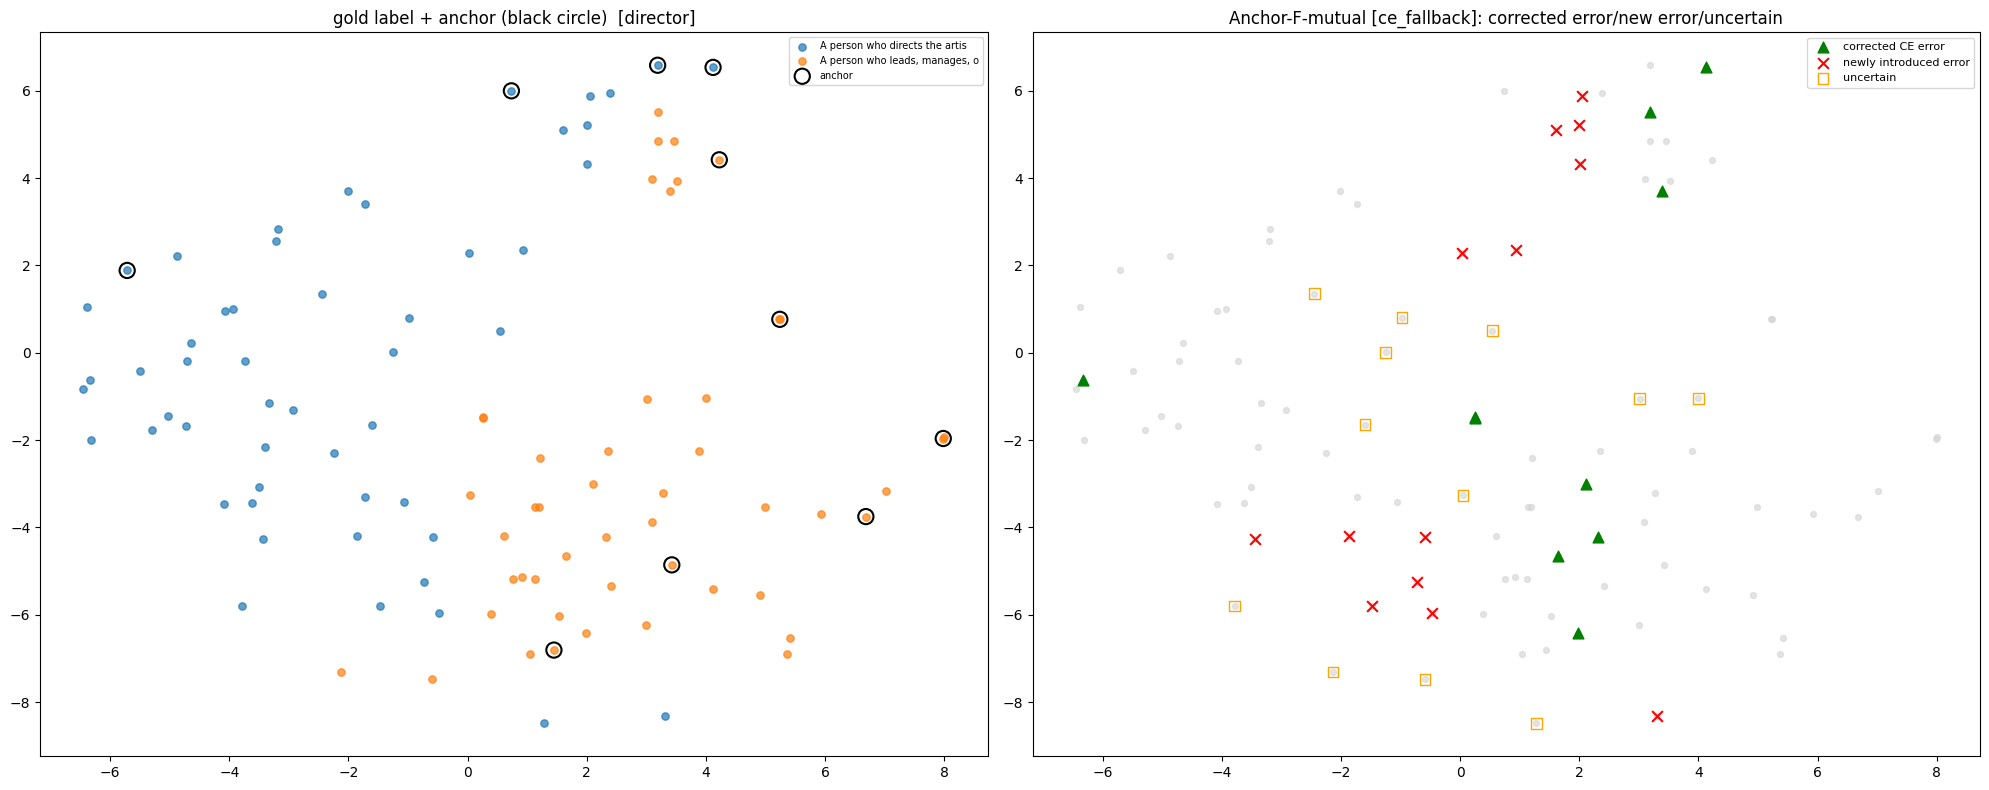

Full CE per-class F1:


,description,gold_count,f1
0,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",52,0.870
1,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",48,0.848


Anchor-F-mutual [ce_fallback] per-class F1:


,description,gold_count,f1
0,"A person who directs the artistic and dramatic aspects of a film, theatre, television, or other performance production.",52,0.809
1,"A person who leads, manages, or oversees an organization, agency, department, program, project, or activity.",48,0.847


In [20]:
# ====== t-SNE 可视化：gold 类着色，标注 anchor / uncertain / 纠错 / 新错 ======
coords = reduce_embeddings(records, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE)
record_indices = [r["record_index"] for r in records]
pos_of_index = {ri: p for p, ri in enumerate(record_indices)}

viz_version, viz_knn_type, viz_umode = "F", "mutual", "ce_fallback"
viz_method = anchor_method_name(viz_version, viz_knn_type, viz_umode)
viz_res = anchor_prop_results[anchor_prop_key(viz_version, viz_knn_type, viz_umode)]
viz_pred = viz_res["pred_by_index"]
viz_anchor = viz_res["anchor_index_set"]
viz_uncertain = viz_res["uncertain_index_set"]

gold_classes = sorted(set(gold_by_index.values()))
color_map = {c: plt.cm.tab10(k % 10) for k, c in enumerate(gold_classes)}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 左：gold 着色 + anchor 标记。
ax = axes[0]
for c in gold_classes:
    pts = [pos_of_index[i] for i in record_indices if gold_by_index[i] == c]
    ax.scatter(coords[pts, 0], coords[pts, 1], s=28, color=color_map[c], label=f"{c[:30]}", alpha=0.7)
anchor_pos = [pos_of_index[i] for i in viz_anchor]
ax.scatter(coords[anchor_pos, 0], coords[anchor_pos, 1], s=120, facecolors="none",
           edgecolors="black", linewidths=1.5, label="anchor")
ax.set_title(f"gold label + anchor (black circle)  [{TARGET_SPAN}]")
ax.legend(fontsize=7, loc="best")

# 右：选定 anchor 方法的纠错 / 新错 / uncertain。
ax = axes[1]
ax.scatter(coords[:, 0], coords[:, 1], s=18, color="lightgray", alpha=0.6)
corrected_pos = [pos_of_index[i] for i in record_indices
                 if ce_top1_by_index[i] != gold_by_index[i] and viz_pred.get(i) == gold_by_index[i]]
newly_pos = [pos_of_index[i] for i in record_indices
             if ce_top1_by_index[i] == gold_by_index[i] and viz_pred.get(i) != gold_by_index[i]]
uncertain_pos = [pos_of_index[i] for i in viz_uncertain]
ax.scatter(coords[corrected_pos, 0], coords[corrected_pos, 1], s=60, color="green", marker="^", label="corrected CE error")
ax.scatter(coords[newly_pos, 0], coords[newly_pos, 1], s=60, color="red", marker="x", label="newly introduced error")
ax.scatter(coords[uncertain_pos, 0], coords[uncertain_pos, 1], s=60, color="orange", marker="s", facecolors="none", label="uncertain")
ax.set_title(f"{viz_method}: corrected error/new error/uncertain")
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

# per-class F1 对比（Full CE vs 当前可视化方法）。
print("Full CE per-class F1:")
display(per_class_f1_frame(ce_top1_by_index, gold_by_index))
print(f"{viz_method} per-class F1:")
display(per_class_f1_frame(viz_pred, gold_by_index))


准确率最高的方法: Anchor-D [re_llm]  (Accuracy: 84.0%)


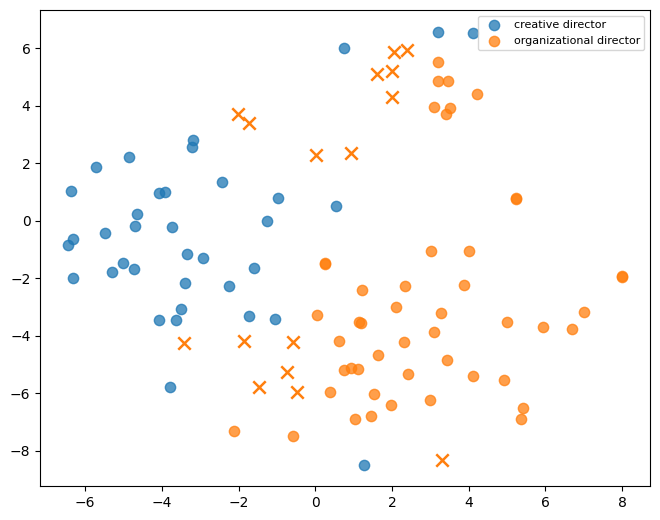

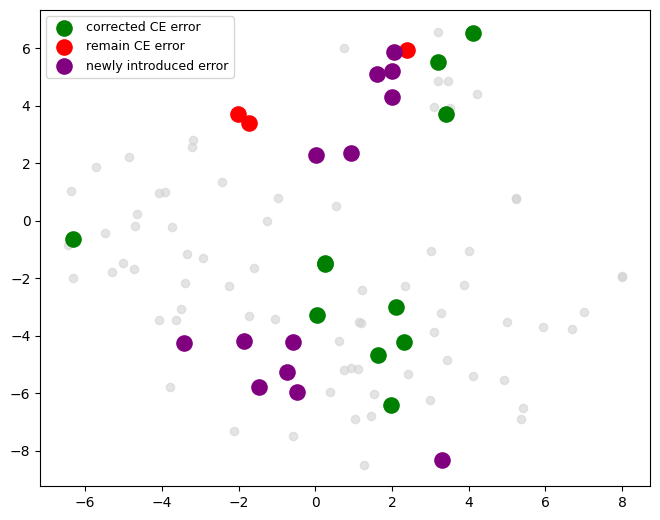

In [21]:
# ====== 重绘可视化：两张独立图、无标题、缩小到约 2/3、增大散点 ======
# 复用上一单元格已算好的 coords / viz_* / color_map 等变量。
# 原 figsize=(20, 8) 两子图（单图约 10x8），缩到约 2/3 → 单图约 (6.7, 5.3)。

# 左图：仅在 anchor 方法（C/D/E/F）中选准确率最高的，按其预测类着色；分类错误的点用叉号(x)表示。
# 图例用候选 label（短），放在坐标区内部；标题只写准确率。
_method_preds = []
for _v, _kt, _um, _ in iter_anchor_prop_specs():
    _res = anchor_prop_results[anchor_prop_key(_v, _kt, _um)]
    _method_preds.append((
        anchor_method_name(_v, _kt, _um),
        _res["pred_by_index"],
        _res["uncertain_index_set"],
    ))

def _method_acc(pred):
    idxs = [i for i in gold_by_index if i in pred]
    if not idxs:
        return 0.0
    return sum(1 for i in idxs if pred[i] == gold_by_index[i]) / len(idxs)

best_name, best_pred, best_uncertain = max(_method_preds, key=lambda t: _method_acc(t[1]))
best_acc = _method_acc(best_pred)
print(f"准确率最高的方法: {best_name}  (Accuracy: {best_acc * 100:.1f}%)")

# description -> 短 label 映射（候选库；uncertain 等无对应项时回退）。
_desc_to_label = {c["description"]: c["label"] for c in candidate_bank}
def _short_label(desc):
    if desc == UNCERTAIN_LABEL:
        return "uncertain"
    return _desc_to_label.get(desc, str(desc)[:20])

pred_classes = sorted({best_pred[i] for i in record_indices if i in best_pred})
pred_color = {c: plt.cm.tab10(k % 10) for k, c in enumerate(pred_classes)}

fig_l, ax_l = plt.subplots(figsize=(6.7, 5.3))
for c in pred_classes:
    correct = [pos_of_index[i] for i in record_indices
               if best_pred.get(i) == c and best_pred.get(i) == gold_by_index.get(i)]
    wrong = [pos_of_index[i] for i in record_indices
             if best_pred.get(i) == c and best_pred.get(i) != gold_by_index.get(i)]
    # label 挂在正确点的散点上（即使为空也会生成图例项）。
    ax_l.scatter(coords[correct, 0], coords[correct, 1], s=55, color=pred_color[c],
                 marker="o", alpha=0.75, label=_short_label(c))
    ax_l.scatter(coords[wrong, 0], coords[wrong, 1], s=80, color=pred_color[c],
                 marker="x", linewidths=1.8)
#ax_l.set_title(f"Accuracy: {best_acc * 100:.1f}%")
ax_l.legend(fontsize=8, loc="best")
fig_l.tight_layout()
plt.show()

# 右图：与左图同一个（准确率最高的）方法的 corrected / remain / newly introduced error。
# 全部用普通圆点，仅靠颜色区分。
# uncertain 会走 LLM fallback：若其原本就是 CE 错（ce_top1 != gold）则算作 corrected；否则不标注。
fig_r, ax_r = plt.subplots(figsize=(6.7, 5.3))
ax_r.scatter(coords[:, 0], coords[:, 1], s=35, color="lightgray", alpha=0.6)
corrected_pos = [
    pos_of_index[i] for i in record_indices
    if ce_top1_by_index[i] != gold_by_index[i]
    and (best_pred.get(i) == gold_by_index[i] or i in best_uncertain)
]
remain_pos = [
    pos_of_index[i] for i in record_indices
    if ce_top1_by_index[i] != gold_by_index[i]
    and best_pred.get(i) != gold_by_index[i]
    and i not in best_uncertain
]
newly_pos = [
    pos_of_index[i] for i in record_indices
    if ce_top1_by_index[i] == gold_by_index[i] and best_pred.get(i) != gold_by_index[i]
]
ax_r.scatter(coords[corrected_pos, 0], coords[corrected_pos, 1], s=120, color="green",
             marker="o", label="corrected CE error")
ax_r.scatter(coords[remain_pos, 0], coords[remain_pos, 1], s=120, color="red",
             marker="o", label="remain CE error")
ax_r.scatter(coords[newly_pos, 0], coords[newly_pos, 1], s=120, color="purple",
             marker="o", label="newly introduced error")
ax_r.legend(fontsize=9, loc="best")
fig_r.tight_layout()
plt.show()
